# TP01 - Parte 2: Datos faltantes y reducción de dimensionalidad

**Bases de Datos Masivas (11088)** - 2° Cuatrimestre 2026

Gustavo An Contardi - 182818

Esta parte cubre los ejercicios 5 (datos faltantes, sobre `alquileres.csv`) y 6 (análisis
de componentes principales, sobre `vehiculos.csv`). La Parte 1 está en `TP01-Parte1.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Semilla única para todo el notebook. Varios métodos del ejercicio 5 (elección de
# donantes en hot deck, particiones) usan azar y quiero que la corrida sea reproducible.
SEMILLA = 42
rng = np.random.default_rng(SEMILLA)

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

In [2]:
# Ruta relativa al notebook, que vive en TPs/TP01/
alq = pd.read_csv("data/alquileres.csv")

print(f"filas: {alq.shape[0]:,} | columnas: {alq.shape[1]}")
alq.head(3)

filas: 29,438 | columnas: 16


,id,barrio,tipo_propiedad,tipo_habitacion,capacidad,banios,dormitorios,camas,precio_ars,minimo_noches,cantidad_resenias,puntaje_resenias,superanfitrion,latitud,longitud,noches_ocupadas_anio
0,11508,Palermo,Entire condo,Entire home/apt,2,1.0,1.0,1.0,185388.0,3.0,52,4.83,si,-34.5820,-58.4240,36
1,13851,Belgrano,Entire condo,Entire home/apt,2,1.0,1.0,1.0,101945.0,2.0,1,5.00,no,-34.5617,-58.4441,0
2,14222,Palermo,Entire rental unit,Entire home/apt,2,NaN,1.0,NaN,NaN,6.0,131,4.78,no,-34.5872,-58.4111,36


## Ejercicio 5. Datos faltantes

> Identifique cuáles de las variables del dataset *alquileres.csv* poseen datos faltantes.
> Aplique los siguientes métodos a efectos de reemplazar esos valores.

El dataset son avisos de alquiler temporario de la Ciudad de Buenos Aires publicados en
Airbnb, relevados el 24 de julio de 2026 por Inside Airbnb. Cada fila es un aviso. La
cátedra tradujo los nombres de las columnas, convirtió el precio a numérico y descartó 171
avisos de más de $1.500.000 por noche, pero **no tocó los faltantes**: los que aparecen acá
son los que trae la fuente.

Esto último importa para todo el ejercicio. No hay un valor verdadero guardado contra el
cual comparar las imputaciones, a diferencia del ejemplo de la guía de la clase 2, donde
los faltantes se habían generado borrando valores a propósito.

### 5a. Tipo de faltante

> Analice el tipo de faltante. ¿Qué puede decir sobre eso?

In [3]:
# Inventario: qué columnas tienen faltantes, cuántos y en qué proporción.
# Agrego la cantidad de valores distintos porque ayuda a separar lo continuo de lo
# discreto, y eso después decide qué medida de tendencia central corresponde en 5b.
inventario = pd.DataFrame({
    "tipo": alq.dtypes.astype(str),
    "faltantes": alq.isna().sum(),
    "pct": (100 * alq.isna().mean()).round(2),
    "distintos": alq.nunique(),
})

# Lista de las variables con faltantes. La uso como constante en todo el ejercicio 5.
FALTAN = inventario.index[inventario.faltantes > 0].tolist()

print("variables con faltantes:", FALTAN)
inventario.sort_values("faltantes", ascending=False)

variables con faltantes: ['banios', 'dormitorios', 'camas', 'precio_ars', 'minimo_noches', 'puntaje_resenias']


,tipo,faltantes,pct,distintos
dormitorios,float64,5814,19.75,21
banios,float64,3599,12.23,23
puntaje_resenias,float64,3537,12.02,140
camas,float64,2566,8.72,30
precio_ars,float64,1918,6.52,13827
minimo_noches,float64,6,0.02,72
id,int64,0,0.00,29438
barrio,str,0,0.00,48
tipo_propiedad,str,0,0.00,57
tipo_habitacion,str,0,0.00,4


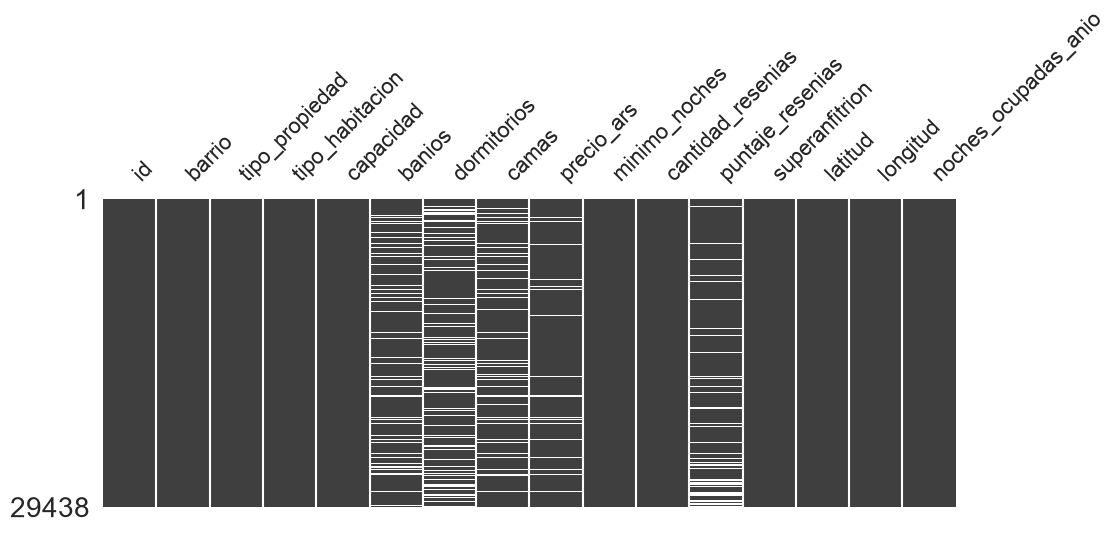

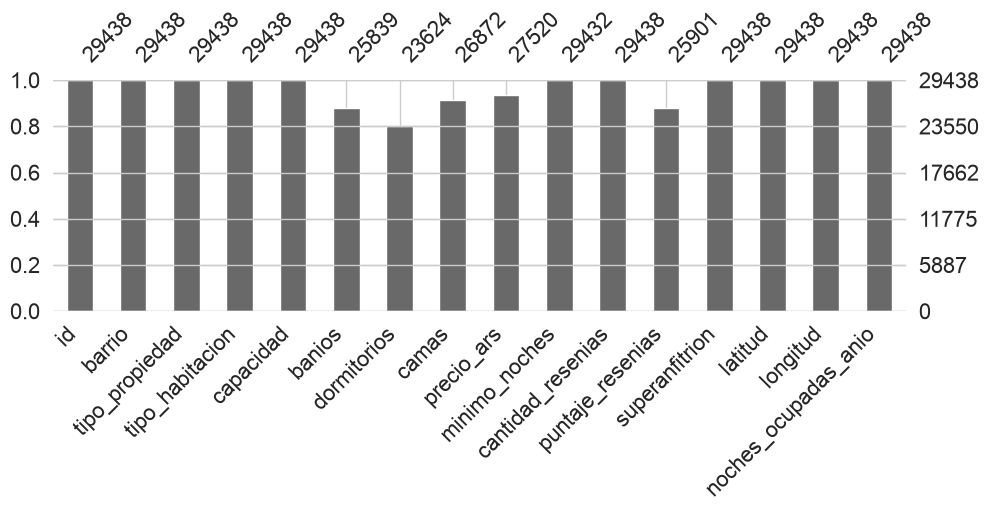

In [4]:
# El inventario da los números, missingno da el patrón: dónde están ubicados los
# faltantes a lo largo del archivo y si hay tramos de filas peores que otros.
msno.matrix(alq, figsize=(11, 4), sparkline=False)
plt.show()

msno.bar(alq, figsize=(11, 3))
plt.show()

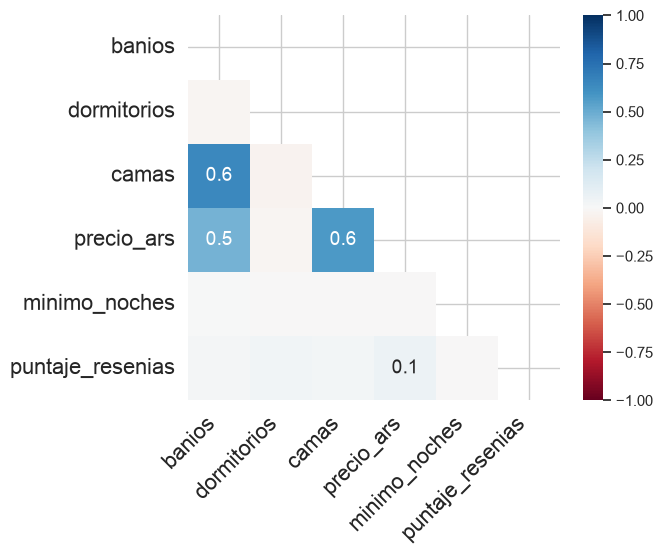

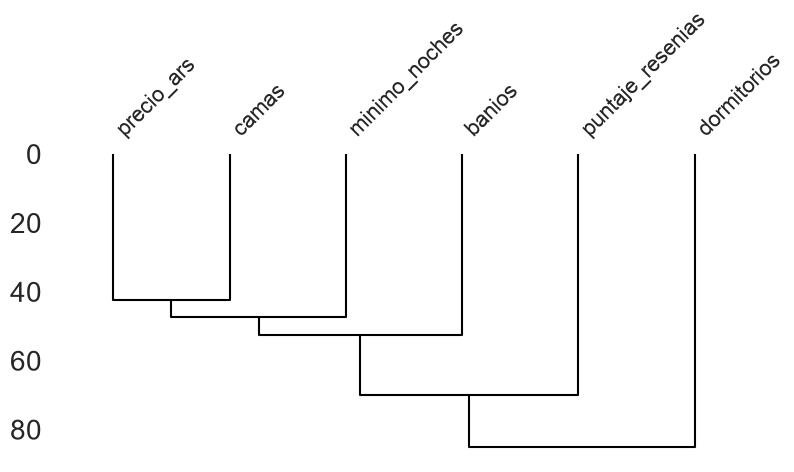

In [5]:
# Restrinjo a las columnas con faltantes: las completas no aportan a estos dos gráficos.
# El heatmap mide correlación de nulidad, o sea si los faltantes de dos variables tienden
# a caer en las mismas filas. El dendrograma agrupa las variables por parecido de patrón.
msno.heatmap(alq[FALTAN], figsize=(6, 5))
plt.show()

msno.dendrogram(alq[FALTAN], figsize=(9, 4))
plt.show()

In [6]:
# Los gráficos anteriores muestran el patrón de a pares. Acá lo cuento exacto: cuáles son
# las combinaciones de faltantes más frecuentes, tomando cada fila como una firma de
# True/False sobre las seis variables.
patrones = (alq[FALTAN].isna()
            .value_counts()
            .head(10)
            .rename("filas")
            .reset_index())
print(patrones.to_string(index=False))

completas = alq.notna().all(axis=1).sum()
print(f"\nfilas completas: {completas:,} ({100 * completas / len(alq):.1f}%)")
print(f"filas con al menos un faltante: {len(alq) - completas:,}")

print("\ncantidad de faltantes por fila:")
print(alq[FALTAN].isna().sum(axis=1).value_counts().sort_index().to_string())

 banios  dormitorios  camas  precio_ars  minimo_noches  puntaje_resenias  filas
  False        False  False       False          False             False  17693
  False         True  False       False          False             False   4297
  False        False  False       False          False              True   2123
   True        False  False       False          False             False   1053
   True        False   True        True          False             False    989
  False         True  False       False          False              True    683
   True        False   True       False          False             False    509
  False        False   True       False          False             False    345
  False        False  False        True          False             False    292
   True         True  False       False          False             False    272

filas completas: 17,693 (60.1%)
filas con al menos un faltante: 11,745

cantidad de faltantes por fila:
0    17693
1   

In [7]:
# Para distinguir MCAR de MAR necesito ver si la tasa de faltantes depende de las
# variables que SÍ están completas. Si la tasa es pareja entre categorías, es compatible
# con MCAR; si cambia fuerte, hay dependencia y eso apunta a MAR.
def tasa_por_grupo(grupos, nombre):
    """Proporción de faltantes de cada variable de FALTAN, dentro de cada grupo."""
    t = alq.groupby(grupos)[FALTAN].apply(lambda g: g.isna().mean())
    t.insert(0, "n", alq.groupby(grupos).size())  # el n avisa qué grupos son chicos
    t.index.name = nombre
    return t.round(3)

for col in ["tipo_habitacion", "superanfitrion"]:
    print(tasa_por_grupo(alq[col], col).to_string(), "\n")

# barrio y tipo_propiedad tienen 48 y 57 categorías. Me quedo con las más frecuentes y
# junto el resto, para que la tabla sea legible y los grupos tengan n suficiente.
for col in ["tipo_propiedad", "barrio"]:
    top = alq[col].value_counts().head(6).index
    agrupado = alq[col].where(alq[col].isin(top), "(resto)")
    print(tasa_por_grupo(agrupado, col).to_string(), "\n")

                     n  banios  dormitorios  camas  precio_ars  minimo_noches  puntaje_resenias
tipo_habitacion                                                                                
Entire home/apt  26574   0.124        0.144  0.089       0.066            0.0             0.104
Hotel room         129   0.116        0.031  0.116       0.016            0.0             0.767
Private room      2590   0.110        0.749  0.064       0.055            0.0             0.240
Shared room        145   0.117        0.283  0.055       0.062            0.0             0.297 

                    n  banios  dormitorios  camas  precio_ars  minimo_noches  puntaje_resenias
superanfitrion                                                                                
no              17156   0.134        0.201  0.101       0.078            0.0             0.184
si              12282   0.105        0.192  0.067       0.047            0.0             0.030 

                                 n  bani

In [8]:
# Mismo análisis, pero contra las variables numéricas completas. Las corto en tramos
# porque la tasa de faltantes no se puede leer valor por valor. El primer tramo de las dos
# primeras es el cero solo, a propósito: un aviso sin reseñas o sin ocupación no es "uno
# con poca", es un caso distinto.
tramos = {
    "cantidad_resenias": pd.cut(alq.cantidad_resenias, [-1, 0, 5, 20, 100, np.inf],
                                labels=["0", "1-5", "6-20", "21-100", "100+"]),
    "noches_ocupadas_anio": pd.cut(alq.noches_ocupadas_anio, [-1, 0, 30, 120, np.inf],
                                   labels=["0", "1-30", "31-120", "120+"]),
    "capacidad": pd.cut(alq.capacidad, [0, 2, 4, 6, np.inf],
                        labels=["1-2", "3-4", "5-6", "7+"]),
}

for nombre, grupos in tramos.items():
    print(tasa_por_grupo(grupos, nombre).to_string(), "\n")

                       n  banios  dormitorios  camas  precio_ars  minimo_noches  puntaje_resenias
cantidad_resenias                                                                                
0                   3537   0.142        0.231  0.107       0.103          0.000               1.0
1-5                 5462   0.140        0.206  0.100       0.073          0.000               0.0
6-20                6737   0.128        0.183  0.098       0.064          0.000               0.0
21-100             10271   0.114        0.184  0.080       0.058          0.000               0.0
100+                3431   0.086        0.219  0.046       0.038          0.001               0.0 

                         n  banios  dormitorios  camas  precio_ars  minimo_noches  puntaje_resenias
noches_ocupadas_anio                                                                               
0                     6834   0.175        0.217  0.143       0.113          0.000             0.518
1-30        

Seis de las dieciséis variables tienen faltantes:

| variable | faltantes | % |
| --- | ---: | ---: |
| `dormitorios` | 5.814 | 19,75 |
| `banios` | 3.599 | 12,23 |
| `puntaje_resenias` | 3.537 | 12,02 |
| `camas` | 2.566 | 8,72 |
| `precio_ars` | 1.918 | 6,52 |
| `minimo_noches` | 6 | 0,02 |

Caen en 11.745 filas, el 39,9 % del dataset. Borrar las filas incompletas me dejaría 17.693
avisos de 29.438, así que no es opción.

El patrón no es el mismo en las seis. Lo separo.

**`puntaje_resenias`.** Falta en 3.537 avisos, que son exactamente los 3.537 con
`cantidad_resenias == 0`. La equivalencia es perfecta en los dos sentidos. No es un valor
que se perdió: un aviso sin reseñas no tiene promedio de reseñas. Es un faltante
estructural. Formalmente es MAR, porque lo determina una variable que observo, pero
imputarlo es inventar una calificación que nunca existió. Lo imputo igual porque el
enunciado lo pide, y lo dejo anotado acá.

En la `msno.matrix` los huecos de esta columna se densifican hacia el final del archivo,
donde están los avisos de alta más reciente. Un aviso nuevo todavía no juntó reseñas.

**`dormitorios`.** Es la que más falta y la que falta más desparejo. Va de 0,144 en *Entire
home/apt* a 0,749 en *Private room*, y a 0,844 en *Private room in rental unit*. Si alquilo
una habitación dentro de una vivienda, cuántos dormitorios tiene la propiedad es una
pregunta sin respuesta, y el anfitrión la saltea. Es MAR, determinada por
`tipo_habitacion`. El efecto de `capacidad` (0,295 en avisos de 1 a 2 personas contra 0,024
en los de 5 a 6) no es un mecanismo aparte: las habitaciones privadas son casi todas de 1 o
2 personas.

**`banios`, `camas` y `precio_ars`.** El heatmap las agrupa, con correlaciones de nulidad de
0,5 y 0,6 entre sí y cerca de cero contra el resto. En 989 filas faltan las tres juntas. Las
tasas son parejas entre barrios y tipos de propiedad, pero bajan al subir las reseñas y la
ocupación: `camas` va de 0,107 en avisos sin reseñas a 0,046 en los de más de cien. Los
faltantes se concentran en los avisos de poca actividad, recién publicados o abandonados.
Son tres campos que carga el anfitrión a mano, y por eso faltan juntos: es una ficha a medio
completar, no tres fallas sueltas. Las trato como MAR.

`precio_ars` tiene algo propio. No es un campo del formulario, es lo que Airbnb muestra el
día del relevamiento, y no aparece si el calendario está bloqueado. Con estos datos no puedo
descartar que falte justo en los avisos más caros. MNAR no lo puedo probar ni descartar, así
que la dejo en MAR con la salvedad.

**`minimo_noches`.** Seis casos, 0,02 %. La completo con la mediana en 5b y no vuelvo sobre
ella.

**`superanfitrion`.** Los avisos con `si` tienen menos faltantes en todas las variables, y
en `puntaje_resenias` la diferencia es 0,030 contra 0,184. No creo que sea que completan
mejor el formulario: para ser superanfitrión hace falta un mínimo de reseñas y actividad
sostenida, así que ese grupo ya está formado por los avisos establecidos. Es síntoma del
mismo nivel de actividad, no causa.

**Conclusión.** Ninguna de las seis es MCAR: todas las tasas se mueven contra alguna
variable observada. Dos consecuencias. Un solo método no va a servir para las seis. Y los
que usan el resto de las variables (hot deck, KNN, regresión) tienen ventaja sobre la media
global, porque la información que predice el faltante está en el dataset.


### 5b. Imputación por una medida de tendencia central

> Sustituya los valores faltantes por una medida de tendencia central según corresponda.

In [9]:
# "Según corresponda" quiere decir elegir la medida que representa el centro de CADA
# variable, no aplicar la misma de taquito. Armo la tabla que justifica esa elección.
medidas = pd.DataFrame({
    "media": alq[FALTAN].mean(),
    "mediana": alq[FALTAN].median(),
    "moda": alq[FALTAN].mode().iloc[0],
    "desvio": alq[FALTAN].std(),
    "asimetria": alq[FALTAN].skew(),
}).round(2)

medidas

,media,mediana,moda,desvio,asimetria
banios,1.24,1.00,1.0,0.67,7.88
dormitorios,1.36,1.00,1.0,0.90,8.03
camas,1.94,1.00,1.0,1.54,6.27
precio_ars,131371.62,103206.00,101945.0,115303.02,4.86
minimo_noches,5.03,2.00,1.0,18.96,16.29
puntaje_resenias,4.78,4.87,5.0,0.36,-5.48


In [10]:
# La máscara de faltantes la guardo ANTES de imputar. Una vez relleno el dataset ya no
# hay forma de distinguir un valor original de uno imputado, y en 5f necesito comparar
# los métodos sobre exactamente las mismas celdas.
MASCARA = alq[FALTAN].isna()
print(f"celdas a imputar: {MASCARA.to_numpy().sum():,}")

# Mediana en las seis. Trabajo sobre una copia para conservar `alq` con los faltantes:
# los otros métodos del ejercicio parten de ahí.
medianas = alq[FALTAN].median()
alq_mediana = alq.copy()
alq_mediana[FALTAN] = alq_mediana[FALTAN].fillna(medianas)

print(f"faltantes después: {alq_mediana[FALTAN].isna().to_numpy().sum()}")
medianas

celdas a imputar: 17,440
faltantes después: 0


banios                   1.00
dormitorios              1.00
camas                    1.00
precio_ars          103206.00
minimo_noches            2.00
puntaje_resenias         4.87
dtype: float64

In [11]:
# Lo que interesa no es que quedó relleno, sino qué le pasó a la distribución.
# Comparo los tres estadísticos contra los originales, calculados sobre los valores
# que sí estaban (pandas ignora los NaN por defecto).
def resumen(df):
    return pd.DataFrame({
        "media": df[FALTAN].mean(),
        "desvio": df[FALTAN].std(),
        "asimetria": df[FALTAN].skew(),
    })

comp = resumen(alq).join(resumen(alq_mediana), lsuffix="_orig", rsuffix="_imp")
comp["desvio_%"] = (100 * (comp.desvio_imp / comp.desvio_orig - 1)).round(1)
comp["pct_imputado"] = (100 * MASCARA.mean()).round(2)

comp[["media_orig", "media_imp", "desvio_orig", "desvio_imp", "desvio_%",
      "asimetria_orig", "asimetria_imp", "pct_imputado"]].round(3)

,media_orig,media_imp,desvio_orig,desvio_imp,desvio_%,asimetria_orig,asimetria_imp,pct_imputado
banios,1.237,1.208,0.675,0.637,-5.6,7.876,8.350,12.23
dormitorios,1.356,1.286,0.905,0.823,-9.1,8.033,8.813,19.75
camas,1.935,1.854,1.539,1.494,-2.9,6.270,6.400,8.72
precio_ars,131371.622,129536.523,115303.022,111699.916,-3.1,4.855,5.041,6.52
minimo_noches,5.031,5.031,18.963,18.961,-0.0,16.293,16.295,0.02
puntaje_resenias,4.779,4.790,0.364,0.343,-5.8,-5.484,-5.875,12.02


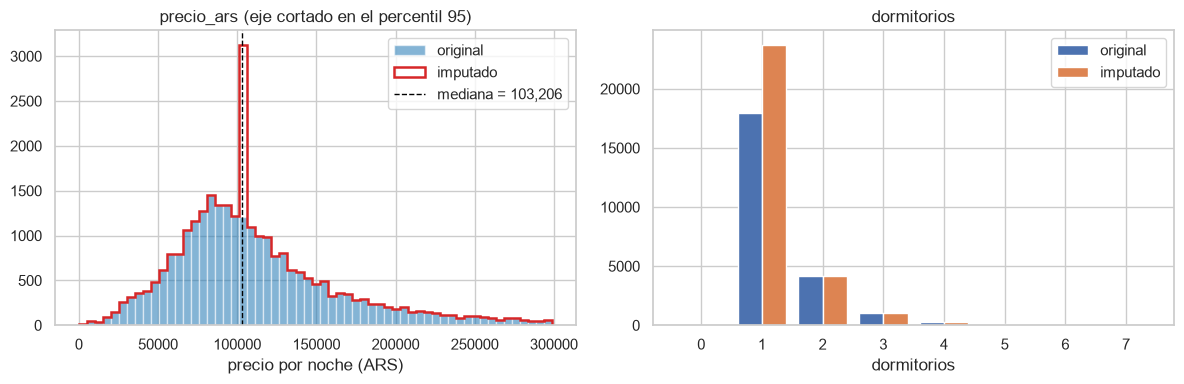

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Corto el eje en el percentil 95 con `range` y NO con clip: si recortara los valores,
# todos los precios altos se apilarían en la última barra y parecería un pico real.
tope = alq.precio_ars.quantile(0.95)
bins = np.linspace(0, tope, 60)
axes[0].hist(alq.precio_ars.dropna(), bins=bins, color="tab:blue", alpha=.55, label="original")
axes[0].hist(alq_mediana.precio_ars, bins=bins, histtype="step", lw=1.8,
             color="tab:red", label="imputado")
axes[0].axvline(medianas.precio_ars, ls="--", color="black", lw=1,
                label=f"mediana = {medianas.precio_ars:,.0f}")
axes[0].set_title("precio_ars (eje cortado en el percentil 95)")
axes[0].set_xlabel("precio por noche (ARS)")
axes[0].legend()

# dormitorios es discreta, así que el histograma no sirve: comparo las frecuencias de
# cada valor con barras apareadas.
orden = sorted(alq.dormitorios.dropna().unique())[:8]
x = np.arange(len(orden))
axes[1].bar(x - 0.2, [alq.dormitorios.eq(v).sum() for v in orden], width=.4, label="original")
axes[1].bar(x + 0.2, [alq_mediana.dormitorios.eq(v).sum() for v in orden], width=.4, label="imputado")
axes[1].set_xticks(x, [int(v) for v in orden])
axes[1].set_title("dormitorios")
axes[1].set_xlabel("dormitorios")
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# Dos cálculos que respaldan afirmaciones del texto y no salen de las tablas anteriores.

# 1) Por qué el orden de la caída del desvío no sigue al de pct_imputado. Lo que falta es
#    cuán lejos de la media cae la mediana, medido en unidades de varianza: si imputo con
#    un valor pegado a la media, cada celda imputada aporta casi nada de dispersión.
lejania = pd.DataFrame({
    "pct_imputado": (100 * MASCARA.mean()).round(2),
    "dist2_sobre_var": ((medianas - alq[FALTAN].mean())**2 / alq[FALTAN].var()).round(3),
    "desvio_%": (100 * (alq_mediana[FALTAN].std() / alq[FALTAN].std() - 1)).round(1),
})
print(lejania.sort_values("desvio_%").to_string())

# 2) Cuánto se infla el valor 1 en dormitorios, que es la variable donde la imputación
#    global hace más daño.
obs_1 = alq.dormitorios.eq(1).sum()
imp_1 = alq_mediana.dormitorios.eq(1).sum()
print(f"\ndormitorios = 1: {obs_1:,} de {alq.dormitorios.notna().sum():,} observados "
      f"({100 * obs_1 / alq.dormitorios.notna().sum():.1f} %)")
print(f"                 {imp_1:,} de {len(alq):,} tras imputar "
      f"({100 * imp_1 / len(alq):.1f} %)")

                  pct_imputado  dist2_sobre_var  desvio_%
dormitorios              19.75            0.155      -9.1
puntaje_resenias         12.02            0.062      -5.8
banios                   12.23            0.123      -5.6
precio_ars                6.52            0.060      -3.1
camas                     8.72            0.369      -2.9
minimo_noches             0.02            0.026      -0.0

dormitorios = 1: 17,933 de 23,624 observados (75.9 %)
                 23,747 de 29,438 tras imputar (80.7 %)


Uso la **mediana en las seis**. Las seis son fuertemente asimétricas (de 4,86 en
`precio_ars` a 16,29 en `minimo_noches`, y -5,48 en `puntaje_resenias`), así que la media
no está en el centro de ninguna. Se ve directo en `minimo_noches`: la media da 5,03 cuando
la mediana es 2, arrastrada por unos pocos avisos de estadía larga. En `banios`,
`dormitorios` y `camas` la moda coincide con la mediana en 1, así que ahí la elección entre
las dos no cambia nada.

La imputación por grupo la dejo para 5c, que es donde el enunciado pide hot deck.

Con eso relleno 17.440 celdas. Los valores son 1 en `banios`, `dormitorios` y `camas`,
2 en `minimo_noches`, 4,87 en `puntaje_resenias` y $103.206 en `precio_ars`.

**El desvío baja en las seis.** Tiene que pasar: estoy agregando miles de observaciones que
no aportan dispersión. La caída va de -9,1 % en `dormitorios` a -0,0 % en `minimo_noches`.

El orden no lo explica solo cuánto imputé. `precio_ars` tiene menos celdas imputadas que
`camas` (6,52 % contra 8,72 %) y sin embargo le baja más el desvío (-3,1 % contra -2,9 %).
Lo que falta mirar es **dónde cae la mediana**. En `precio_ars` la mediana está cerca de la
media en relación a la dispersión de la variable: la distancia al cuadrado entre las dos es
el 6 % de la varianza. En `camas` la mediana es 1, que además es el mínimo, así que no está
en el centro sino en el borde, y esa distancia al cuadrado es el 37 % de la varianza. Cada
valor que imputo en `camas` queda lejos de la media y por eso "devuelve" parte de la
dispersión que la constante le quitaba.

**La media casi no se mueve.** Se corre un poco y siempre hacia la mediana: `dormitorios`
pasa de 1,356 a 1,286. El corrimiento es la proporción imputada por la distancia entre
mediana y media, y las dos son chicas. Si hubiera imputado con la media, no se movería
nada: quedaría idéntica por construcción. Esa es la ventaja que tiene la media y la razón
por la que se usa, pero conserva el centro rompiendo todo lo demás.

**La asimetría sube en valor absoluto en las seis.** Al apilar miles de casos en un solo
punto la distribución se vuelve más puntiaguda y las colas quedan relativamente más lejos.
En `puntaje_resenias` se va de -5,48 a -5,88, o sea que se hace más asimétrica hacia la
izquierda, no menos.

**El pico del histograma de `precio_ars` son 1.918 avisos** que ahora valen exactamente
$103.206. Fuera de esa barra el contorno rojo se superpone con el azul, porque la
imputación no toca ningún otro valor. Es todo el daño concentrado en un punto.

**En `dormitorios` el problema es peor de lo que muestra el desvío.** La barra del valor 1
pasa de 17.933 a 23.747 avisos, del 75,9 % de los datos observados al 80,7 % del total. Y
en 5a vi que ese faltante se concentra en las habitaciones privadas, donde falta en el
74,9 % de los casos. Ponerles 1 es afirmar que la propiedad tiene un dormitorio, que es
justo el caso que no aplica. Le estoy asignando al grupo que falta el valor típico de otro
grupo, el de los monoambientes enteros.

**Conclusión.** La imputación por tendencia central es el piso contra el cual comparar. No
pierdo filas y la media queda casi igual, pero achico el desvío, deformo la asimetría y
meto un pico artificial en cada variable. Y sobre todo no uso nada de lo que sé: en 5a vi
que el faltante depende de `tipo_habitacion`, de las reseñas y de la ocupación, y acá le
pongo el mismo número a todos. Eso es lo que van a aprovechar los métodos que siguen.

### 5c. Hot deck

> Sustituya los valores faltantes de acuerdo al método de "hot deck imputation".

Hot deck no es imputar con la medida de tendencia central del grupo. El valor que entra es
un **valor observado de otro registro real** del mismo dataset, el donante, y el grupo solo
define de dónde se puede sacar. Por eso la distribución imputada conserva la forma de la
original en lugar de apilar todo en un punto.

In [14]:
# Los estratos definen el "mazo" del que sale cada donante. Uso tipo_habitacion cruzado
# con la capacidad agrupada: es el corte que más explica el precio (R² 0,311 sobre el log,
# más que agregar el barrio) y, sobre todo, no deja ninguna celda sin donantes.
capacidad_grupo = pd.cut(alq.capacidad, [0, 2, 4, 6, np.inf],
                         labels=["1-2", "3-4", "5-6", "7+"])

# Concateno en una sola clave de texto para que el groupby y los gráficos queden legibles.
ESTRATO = alq.tipo_habitacion.str.cat(capacidad_grupo.astype(str), sep=" | ").rename("estrato")

# Antes de imputar reviso cuántos donantes tiene cada celda para cada variable. Si alguna
# diera 0, ese faltante no tendría a quién copiarle.
donantes = pd.DataFrame({"n": ESTRATO.value_counts()})
for c in FALTAN:
    donantes[c] = alq.groupby(ESTRATO, observed=True)[c].apply(lambda s: s.notna().sum())

print(f"celdas: {ESTRATO.nunique()} | mínimo de donantes en una celda: "
      f"{donantes[FALTAN].to_numpy().min()}")
donantes.sort_values("n", ascending=False)

celdas: 14 | mínimo de donantes en una celda: 1


,n,banios,dormitorios,camas,precio_ars,minimo_noches,puntaje_resenias
estrato,,,,,,,
Entire home/apt | 1-2,13234,11582,10411,11970,12316,13232,11826
Entire home/apt | 3-4,10773,9433,9810,9863,10045,10771,9681
Private room | 1-2,2266,2017,494,2115,2143,2266,1731
Entire home/apt | 5-6,1950,1717,1919,1783,1851,1948,1753
Entire home/apt | 7+,617,559,606,582,598,617,540
Private room | 3-4,255,228,108,241,240,255,192
Shared room | 1-2,112,101,75,104,103,112,79
Hotel room | 1-2,102,91,99,89,100,102,22
Private room | 5-6,43,40,26,42,39,43,28


In [15]:
def hot_deck(df, columnas, estratos, semilla):
    """Hot deck aleatorio dentro de clase, una variable por vez.

    Para cada variable y cada estrato, sortea con reposición entre los valores observados
    de ese estrato. Si un estrato no tiene ningún donante cae al dataset completo, que es
    el respaldo. Devuelve también la lista de veces que tuvo que usarlo.
    """
    # El generador se crea acá adentro y no afuera, para que volver a correr la celda dé
    # siempre el mismo resultado en vez de seguir consumiendo el `rng` global.
    rng = np.random.default_rng(semilla)
    out = df.copy()
    respaldos = []

    for c in columnas:
        falta = df[c].isna()
        for clave, idx in df.groupby(estratos, observed=True).groups.items():
            objetivo = idx[falta.loc[idx]]
            if len(objetivo) == 0:
                continue
            disponibles = df.loc[idx, c].dropna().to_numpy()
            if len(disponibles) == 0:
                disponibles = df[c].dropna().to_numpy()
                respaldos.append((c, clave, len(objetivo)))
            # Con reposición: un donante puede ser elegido más de una vez, que es lo
            # habitual cuando el estrato tiene pocos donantes y muchos faltantes.
            out.loc[objetivo, c] = rng.choice(disponibles, size=len(objetivo), replace=True)

    return out, respaldos


alq_hotdeck, respaldos = hot_deck(alq, FALTAN, ESTRATO, SEMILLA)

print(f"faltantes después: {alq_hotdeck[FALTAN].isna().to_numpy().sum()}")
print(f"veces que se usó el respaldo global: {len(respaldos)}")
print(f"valores distintos usados para imputar precio_ars: "
      f"{alq_hotdeck.loc[MASCARA.precio_ars, 'precio_ars'].nunique():,} "
      f"de {MASCARA.precio_ars.sum():,} celdas")

faltantes después: 0
veces que se usó el respaldo global: 0
valores distintos usados para imputar precio_ars: 1,549 de 1,918 celdas


In [16]:
# Comparo contra el original y contra la imputación por mediana de 5b.
def resumen(df, etiqueta):
    return pd.DataFrame({
        (etiqueta, "media"): df[FALTAN].mean(),
        (etiqueta, "desvio"): df[FALTAN].std(),
        (etiqueta, "asimetria"): df[FALTAN].skew(),
    })

comp_hd = pd.concat([resumen(alq, "original"),
                     resumen(alq_mediana, "mediana"),
                     resumen(alq_hotdeck, "hot deck")], axis=1)
display(comp_hd.round(3))

# Lo mismo en una sola columna por método: cuánto se desvía del desvío original.
pd.DataFrame({
    "mediana_%": (100 * (alq_mediana[FALTAN].std() / alq[FALTAN].std() - 1)).round(1),
    "hotdeck_%": (100 * (alq_hotdeck[FALTAN].std() / alq[FALTAN].std() - 1)).round(1),
})

original                           mediana                          hot deck                      
                       media      desvio asimetria       media      desvio asimetria       media      desvio asimetria
banios                 1.237       0.675     7.876       1.208       0.637     8.350       1.236       0.669     7.643
dormitorios            1.356       0.905     8.033       1.286       0.823     8.813       1.387       1.143     8.852
camas                  1.935       1.539     6.270       1.854       1.494     6.400       1.929       1.523     6.208
precio_ars        131371.622  115303.022     4.855  129536.523  111699.916     5.041  130964.921  114736.112     4.909
minimo_noches          5.031      18.963    16.293       5.031      18.961    16.295       5.031      18.961    16.295
puntaje_resenias       4.779       0.364    -5.484       4.790       0.343    -5.875       4.775       0.372    -5.365

,mediana_%,hotdeck_%
banios,-5.6,-0.9
dormitorios,-9.1,26.4
camas,-2.9,-1.0
precio_ars,-3.1,-0.5
minimo_noches,-0.0,-0.0
puntaje_resenias,-5.8,2.1


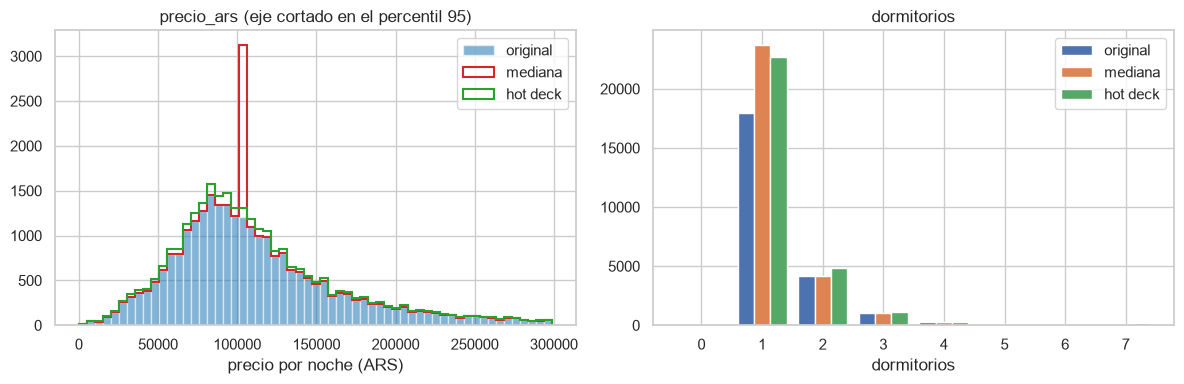

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tope = alq.precio_ars.quantile(0.95)
bins = np.linspace(0, tope, 60)
axes[0].hist(alq.precio_ars.dropna(), bins=bins, color="tab:blue", alpha=.55, label="original")
axes[0].hist(alq_mediana.precio_ars, bins=bins, histtype="step", lw=1.5, color="tab:red", label="mediana")
axes[0].hist(alq_hotdeck.precio_ars, bins=bins, histtype="step", lw=1.5, color="tab:green", label="hot deck")
axes[0].set_title("precio_ars (eje cortado en el percentil 95)")
axes[0].set_xlabel("precio por noche (ARS)")
axes[0].legend()

orden = sorted(alq.dormitorios.dropna().unique())[:8]
x = np.arange(len(orden))
for k, (d, lab) in enumerate([(alq, "original"), (alq_mediana, "mediana"), (alq_hotdeck, "hot deck")]):
    axes[1].bar(x + (k - 1) * 0.27, [d.dormitorios.eq(v).sum() for v in orden], width=.27, label=lab)
axes[1].set_xticks(x, [int(v) for v in orden])
axes[1].set_title("dormitorios")
axes[1].set_xlabel("dormitorios")
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# Los tres números que cito en el texto y que no salen de las tablas anteriores.

# 1) Cuánto explica cada corte de la variación del precio. Uso el log porque el precio es
#    muy asimétrico y en escala original el R² lo domina la cola. La fórmula es la de
#    siempre: uno menos la varianza que queda dentro de los grupos sobre la varianza total.
def r2_grupos(y, grupos):
    d = pd.DataFrame({"y": y, "g": grupos.astype(str)}).dropna()
    residuo = d.y - d.groupby("g", observed=True).y.transform("mean")
    return 1 - residuo.var(ddof=0) / d.y.var(ddof=0)

log_precio = np.log(alq.precio_ars)
cortes = {
    "barrio": alq.barrio,
    "tipo_habitacion": alq.tipo_habitacion,
    "capacidad agrupada": capacidad_grupo,
    "tipo_habitacion x barrio": alq.tipo_habitacion.str.cat(alq.barrio, sep=" | "),
    "tipo_habitacion x capacidad (elegido)": ESTRATO,
}
print(pd.Series({n: round(r2_grupos(log_precio, g), 3) for n, g in cortes.items()},
                name="R2 de log(precio_ars)").to_string())

# 2) Quiénes son los donantes de dormitorios en el estrato donde cae el grueso del faltante.
sub = alq[ESTRATO.eq("Private room | 1-2")]
print(f"\nPrivate room | 1-2: {len(sub):,} avisos | {sub.dormitorios.notna().sum():,} donantes "
      f"de dormitorios | {sub.dormitorios.isna().sum():,} faltantes")

display(pd.DataFrame({
    "media": [sub.dormitorios.mean(), alq.dormitorios.mean()],
    "desvio": [sub.dormitorios.std(), alq.dormitorios.std()],
    "maximo": [sub.dormitorios.max(), alq.dormitorios.max()],
}, index=["donantes del estrato", "dataset entero"]).round(2))

# 3) Los casos que arrastran ese desvío: no son habitaciones en un departamento.
print("valores de 10 o más dormitorios entre esos donantes:")
print(sub.dormitorios[sub.dormitorios.ge(10)].value_counts().sort_index().to_string())

barrio                                   0.078
tipo_habitacion                          0.127
capacidad agrupada                       0.221
tipo_habitacion x barrio                 0.185
tipo_habitacion x capacidad (elegido)    0.311

Private room | 1-2: 2,266 avisos | 494 donantes de dormitorios | 1,772 faltantes


,media,desvio,maximo
donantes del estrato,2.42,3.24,31.0
dataset entero,1.36,0.90,31.0


valores de 10 o más dormitorios entre esos donantes:
dormitorios
10.0    3
11.0    5
14.0    1
19.0    1
20.0    1
22.0    1
29.0    1
31.0    1


Uso hot deck **aleatorio dentro de clase**, con un donante sorteado por variable y semilla
fija. Descarté la variante secuencial, que arrastra el último valor observado: mi archivo
está ordenado por antigüedad del aviso, así que cada faltante heredaría el valor de un
aviso más viejo y eso mete un sesgo que no controlo.

Los estratos son `tipo_habitacion` × capacidad agrupada (1-2, 3-4, 5-6, 7+). Elegí ese
corte por dos razones. Es el que más explica el precio, R² 0,311 sobre el log, contra 0,185
si cruzo `tipo_habitacion` con `barrio` y 0,078 con el barrio solo. Me sorprendió: en
alquileres uno espera que mande la ubicación, y acá pesa más cuánta gente entra. Y además
es el corte más fino que no deja ninguna celda sin donantes. Con 14 celdas, la más chica
tiene 2 avisos.

El resultado confirma lo segundo: el respaldo global no se usó ni una vez. Las 17.440
celdas se llenaron con valores de donantes reales del mismo estrato. Para `precio_ars` se
usaron 1.549 valores distintos en 1.918 celdas.

**El hot deck conserva el desvío y la mediana no.** La caída pasa de -5,6 % a -0,9 % en
`banios`, de -2,9 % a -1,0 % en `camas`, de -3,1 % a -0,5 % en `precio_ars`. La razón es
directa: la mediana mete la misma constante 1.918 veces, que no aporta dispersión, y el hot
deck mete 1.549 valores distintos sacados de toda la distribución. En el histograma se ve
sin ambigüedad. El contorno rojo de la mediana tiene un pico de 1.918 avisos en $103.206.
El verde del hot deck no tiene pico: sigue la forma de la distribución original, un poco
más alto en todo el rango porque agrega casos sin cambiar la proporción entre los tramos.

**Pero conservar el desvío no es un objetivo en sí.** En `dormitorios` el desvío no baja,
sube 26,4 %, y la media pasa de 1,356 a 1,387. Eso es peor que lo que hacía la mediana, no
mejor.

La explicación está en el estrato `Private room | 1-2`, que es donde cae el grueso del
faltante. Tiene 2.266 avisos y solo 494 declaran `dormitorios`. Esos 494 tienen media 2,42
y desvío 3,24, contra 1,36 y 0,90 del dataset entero, y hay casos de 20, 29 y 31
dormitorios. No son habitaciones en un departamento particular: son hostels y pensiones que
publican habitaciones privadas dentro de un edificio grande, y declaran los dormitorios del
edificio.

O sea que el estrato mezcla dos poblaciones, y los que completan el dato son casi todos de
una sola. El hot deck copia de ellos a los 1.772 que faltan, que son en su mayoría de la
otra. No conserva la dispersión original, importa la de otro grupo.

Eso me deja una conclusión sobre el método: **el hot deck vale lo que valga la definición
del estrato**. Si el estrato es homogéneo, copia bien. Si adentro hay dos poblaciones y el
faltante no está repartido parejo entre ellas, copia mal y encima lo hace con una
distribución que parece sana. El corte que elegí es bueno para el precio y malo para
`dormitorios`, y un estrato único para las seis variables es siempre un compromiso.

**`puntaje_resenias` sigue sin arreglo.** El desvío sube 2,1 %, así que por la métrica
parece mejor que la mediana. Pero lo que está pasando es que a un aviso sin ninguna reseña
le copio el puntaje de un aviso que sí tiene. En 5a vi que ese faltante es estructural.
Cambia la forma del resultado, no el sinsentido de fondo. Ningún método de imputación
resuelve un dato que no existe.

**Dos limitaciones más.** En las celdas chicas el sorteo casi no elige: `Shared room | 7+`
tiene 2 avisos y un solo donante para `puntaje_resenias`, así que ahí el donante está
determinado. Y como sorteo un donante por variable y no una fila entera, puedo armar avisos
incoherentes, por ejemplo 1 dormitorio con 6 camas. La alternativa era copiar la fila
completa del mismo donante, que preserva la relación entre variables pero deja muchos menos
donantes elegibles.

### 5d. Hot deck por similitud contra KNNImputer

> Implemente una función *hot_deck* en python siguiendo el criterio explicado en clase de
> hot deck y compare los resultados obtenidos con los del módulo KNNImputer de Sklearn.
> Defina el criterio de similitud que crea adecuado para el dataset *alquileres.csv*

En 5c el parecido era binario: dos avisos estaban en la misma celda o no. Acá el parecido
es una distancia, y hay que definir sobre qué se mide.

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.impute import KNNImputer

# Criterio de similitud: distancia euclídea sobre las cinco variables numéricas que están
# COMPLETAS. Las elijo así para que la distancia nunca dependa de un valor que a su vez
# está imputado, y porque son las que 5a señaló como ligadas al faltante: la capacidad
# ordena dormitorios y camas, y las reseñas y la ocupación marcan el nivel de actividad.
# lat/long entran casi gratis y aportan la ubicación.
COMPLETAS = ["capacidad", "cantidad_resenias", "latitud", "longitud", "noches_ocupadas_anio"]

# Estandarizar no es opcional. Sin escalar, cantidad_resenias se mueve en un rango de 1.117
# y la latitud en 0,155: el vecino "más cercano" se decidiría solo por las reseñas y la
# ubicación no pesaría nada.
escalador_sim = StandardScaler()
Z = escalador_sim.fit_transform(alq[COMPLETAS])

pd.DataFrame({
    "rango original": alq[COMPLETAS].max() - alq[COMPLETAS].min(),
    "desvio original": alq[COMPLETAS].std(),
    "desvio escalado": Z.std(axis=0),
}, index=COMPLETAS).round(3)

,rango original,desvio original,desvio escalado
capacidad,15.000,1.552,1.0
cantidad_resenias,1117.000,59.990,1.0
latitud,0.155,0.018,1.0
longitud,0.175,0.030,1.0
noches_ocupadas_anio,255.000,82.658,1.0


In [20]:
def hot_deck_similitud(df, columnas, Z, bloques, k, semilla):
    """Hot deck por vecinos más cercanos, con restricción dura por bloque.

    El donante tiene que (a) estar en el mismo bloque que el receptor y (b) ser uno de los
    k más cercanos en el espacio Z. Entre esos k se sortea uno y se copia su valor tal cual.
    Sortear en vez de tomar siempre el primero evita que un donante muy "central" termine
    copiado cientos de veces, e iguala el k de KNNImputer para que la comparación no se
    juegue ahí.
    """
    rng = np.random.default_rng(semilla)
    out = df.copy()
    sin_donantes = []

    for bloque, idx in df.groupby(bloques, observed=True).groups.items():
        # Las filas del bloque, en el mismo orden en Z que en el DataFrame.
        Zb = Z[df.index.get_indexer(idx)]

        for c in columnas:
            tiene = df.loc[idx, c].notna().to_numpy()
            objetivo = ~tiene
            if objetivo.sum() == 0:
                continue
            if tiene.sum() == 0:
                sin_donantes.append((c, bloque, int(objetivo.sum())))
                continue

            # Busco vecinos SOLO entre los donantes del bloque, así los índices que
            # devuelve kneighbors ya apuntan a filas que tienen el dato.
            k_ef = min(k, int(tiene.sum()))
            _, vecinos = NearestNeighbors(n_neighbors=k_ef).fit(Zb[tiene]).kneighbors(Zb[objetivo])

            elegido = rng.integers(0, k_ef, size=len(vecinos))
            donante = vecinos[np.arange(len(vecinos)), elegido]
            out.loc[idx[objetivo], c] = df.loc[idx, c].to_numpy()[tiene][donante]

    return out, sin_donantes


# El bloque es tipo_habitacion: un departamento entero no puede donarle a una habitación
# privada por más cerca que esté en la distancia.
alq_hd_sim, sin_donantes = hot_deck_similitud(alq, FALTAN, Z, alq.tipo_habitacion, 5, SEMILLA)

print(f"faltantes después: {alq_hd_sim[FALTAN].isna().to_numpy().sum()}")
print(f"bloques sin donantes: {len(sin_donantes)}")

faltantes después: 0
bloques sin donantes: 0


In [21]:
NUM = ["capacidad", "banios", "dormitorios", "camas", "precio_ars", "minimo_noches",
       "cantidad_resenias", "puntaje_resenias", "latitud", "longitud", "noches_ocupadas_anio"]

def imputar_knn(columnas, escalar, k=5):
    """KNNImputer, con y sin estandarizar. Al escalar hay que volver a las unidades
    originales con inverse_transform, si no los valores imputados quedan en z."""
    if not escalar:
        Y = KNNImputer(n_neighbors=k, weights="distance").fit_transform(alq[columnas].to_numpy())
    else:
        sc = StandardScaler()
        Xs = sc.fit_transform(alq[columnas])      # StandardScaler ignora los NaN
        Y = sc.inverse_transform(KNNImputer(n_neighbors=k, weights="distance").fit_transform(Xs))
    return pd.DataFrame(Y, columns=columnas, index=alq.index)

# a) Las 11 numéricas escaladas: el uso natural del módulo.
alq_knn = alq.copy()
alq_knn[FALTAN] = imputar_knn(NUM, escalar=True)[FALTAN]

# b) Sin escalar, para ver qué pasa cuando una variable domina la distancia.
alq_knn_sin = alq.copy()
alq_knn_sin[FALTAN] = imputar_knn(NUM, escalar=False)[FALTAN]

# c) Mismo criterio de similitud que mi función: las 5 completas más la variable que se
#    está imputando. Es la comparación que aísla copiar contra promediar.
alq_knn5 = alq.copy()
for c in FALTAN:
    alq_knn5[c] = imputar_knn(COMPLETAS + [c], escalar=True)[c]

print("listo")

listo


In [22]:
metodos = {
    "mediana (5b)": alq_mediana,
    "hot deck estratos (5c)": alq_hotdeck,
    "hot deck similitud": alq_hd_sim,
    "KNN 11 cols": alq_knn,
    "KNN 5+objetivo": alq_knn5,
    "KNN sin escalar": alq_knn_sin,
}

print("desvío, % respecto del original:")
display(pd.DataFrame({n: (100 * (d[FALTAN].std() / alq[FALTAN].std() - 1)).round(1)
                      for n, d in metodos.items()}))

# Cuántos valores DISTINTOS produce cada método. El hot deck sólo puede devolver valores
# que existen en el dataset; el promedio de KNN inventa valores nuevos.
print("\nvalores distintos entre las celdas imputadas:")
display(pd.DataFrame({n: {c: int(d.loc[MASCARA[c], c].nunique()) for c in FALTAN}
                      for n, d in metodos.items()}))

# Y si esos valores son posibles: dormitorios, camas y minimo_noches son conteos.
enteras = ["dormitorios", "camas", "minimo_noches"]
print("\n% de valores imputados que no son enteros:")
display(pd.DataFrame({n: {c: round(100 * float((d.loc[MASCARA[c], c] % 1 != 0).mean()), 1)
                          for c in enteras} for n, d in metodos.items()}))

desvío, % respecto del original:


,mediana (5b),hot deck estratos (5c),hot deck similitud,KNN 11 cols,KNN 5+objetivo,KNN sin escalar
banios,-5.6,-0.9,-0.0,-2.9,-2.8,-5.3
dormitorios,-9.1,26.4,13.4,-6.4,-4.2,-8.7
camas,-2.9,-1.0,-0.7,-1.6,-1.5,-3.5
precio_ars,-3.1,-0.5,-1.0,-2.0,-2.0,-1.3
minimo_noches,-0.0,-0.0,-0.0,-0.0,-0.0,0.0
puntaje_resenias,-5.8,2.1,20.9,-1.2,2.3,1.3



valores distintos entre las celdas imputadas:


,mediana (5b),hot deck estratos (5c),hot deck similitud,KNN 11 cols,KNN 5+objetivo,KNN sin escalar
banios,1,15,14,1936,2040,2351
dormitorios,1,18,16,1255,1598,2553
camas,1,14,14,1914,1861,2255
precio_ars,1,1549,1533,1917,1916,1914
minimo_noches,1,4,3,6,6,6
puntaje_resenias,1,109,75,3229,2847,2606



% de valores imputados que no son enteros:


,mediana (5b),hot deck estratos (5c),hot deck similitud,KNN 11 cols,KNN 5+objetivo,KNN sin escalar
dormitorios,0.0,0.0,0.0,23.8,29.7,44.4
camas,0.0,0.0,0.0,84.7,81.9,87.8
minimo_noches,0.0,0.0,0.0,100.0,100.0,100.0


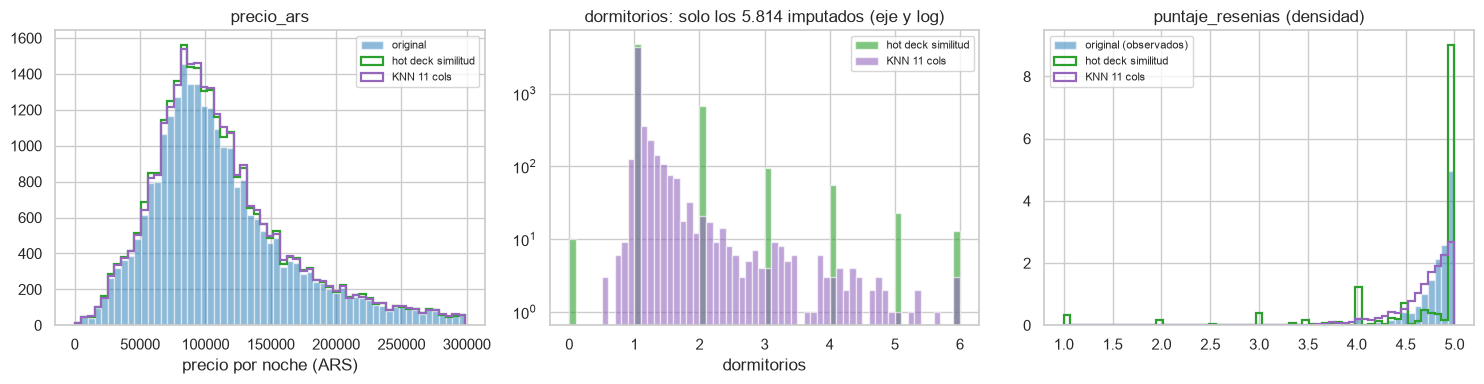

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

tope = alq.precio_ars.quantile(0.95)
bins = np.linspace(0, tope, 60)
axes[0].hist(alq.precio_ars.dropna(), bins=bins, color="tab:blue", alpha=.5, label="original")
axes[0].hist(alq_hd_sim.precio_ars, bins=bins, histtype="step", lw=1.6, color="tab:green", label="hot deck similitud")
axes[0].hist(alq_knn.precio_ars, bins=bins, histtype="step", lw=1.6, color="tab:purple", label="KNN 11 cols")
axes[0].set_title("precio_ars"); axes[0].set_xlabel("precio por noche (ARS)"); axes[0].legend(fontsize=8)

# Sólo las celdas imputadas, y con eje log porque el valor 1 aplasta todo lo demás.
b2 = np.arange(0, 6.1, 0.1)
axes[1].hist(alq_hd_sim.loc[MASCARA.dormitorios, "dormitorios"], bins=b2, color="tab:green", alpha=.6, label="hot deck similitud")
axes[1].hist(alq_knn.loc[MASCARA.dormitorios, "dormitorios"], bins=b2, color="tab:purple", alpha=.6, label="KNN 11 cols")
axes[1].set_yscale("log")
axes[1].set_title("dormitorios: solo los 5.814 imputados (eje y log)")
axes[1].set_xlabel("dormitorios"); axes[1].legend(fontsize=8)

b3 = np.linspace(1, 5, 60)
axes[2].hist(alq.puntaje_resenias.dropna(), bins=b3, density=True, color="tab:blue", alpha=.5, label="original (observados)")
axes[2].hist(alq_hd_sim.loc[MASCARA.puntaje_resenias, "puntaje_resenias"], bins=b3, density=True, histtype="step", lw=1.6, color="tab:green", label="hot deck similitud")
axes[2].hist(alq_knn.loc[MASCARA.puntaje_resenias, "puntaje_resenias"], bins=b3, density=True, histtype="step", lw=1.6, color="tab:purple", label="KNN 11 cols")
axes[2].set_title("puntaje_resenias (densidad)"); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

**El criterio de similitud.** Mido la distancia euclídea sobre las cinco variables numéricas
que están completas: `capacidad`, `cantidad_resenias`, `latitud`, `longitud` y
`noches_ocupadas_anio`. Las elegí completas a propósito, para que la distancia nunca dependa
de un valor que a su vez está imputado. Y son las que 5a señaló como ligadas al faltante: la
capacidad ordena `dormitorios` y `camas`, las reseñas y la ocupación marcan el nivel de
actividad del aviso, y lat/long entran casi gratis y aportan la ubicación.

Las estandarizo antes de medir. Sin escalar, `cantidad_resenias` se mueve en un rango de
1.117 y la latitud en 0,155: el vecino más cercano se decidiría solo por las reseñas.

Agrego una restricción dura: el donante tiene que compartir `tipo_habitacion`. Un
departamento entero no le dona a una habitación privada por más cerca que esté. Y entre los
5 vecinos más cercanos sorteo uno, en vez de tomar siempre el primero, para que un donante
muy central no termine copiado cientos de veces. Ese 5 iguala el `n_neighbors` de
`KNNImputer`, así la comparación se juega en lo que importa y no en el valor de k.

**La diferencia de fondo es copiar contra promediar.** Mi `hot_deck` devuelve el valor de un
donante real. `KNNImputer` devuelve el promedio ponderado de los 5 vecinos, que es un valor
que no existe en el dataset.

Eso se ve en la cantidad de valores distintos que produce cada uno. En `dormitorios` el hot
deck usa 16 valores y `KNNImputer` 1.255. No es que el segundo sea más rico: es que inventa.
El 23,8 % de los `dormitorios` que imputa no son enteros, el 84,7 % de las `camas` tampoco y
en `minimo_noches` es el **100 %**. Un aviso con 2,4 noches mínimas no existe. En el gráfico
del medio se ve directo: el hot deck deja barras en 1, 2, 3 y 4, y `KNNImputer` una nube
continua entre ellas.

Para variables de conteo eso me alcanza para preferir el hot deck. El promedio no es un
valor posible del dominio.

**En dispersión también gana el hot deck**, en casi todas. El desvío queda en -0,0 % en
`banios`, -0,7 % en `camas` y -1,0 % en `precio_ars`, contra -2,9 %, -1,6 % y -2,0 % de
`KNNImputer`. Promediar cinco vecinos achica la varianza, bastante menos que una constante
pero la achica igual.

**En `dormitorios` el criterio de similitud arregló la mitad del problema.** Venía de +26,4 %
con los estratos de 5c. Con la distancia baja a +13,4 %. La razón es que `cantidad_resenias`
y `noches_ocupadas_anio` separan en parte a los hostels de las habitaciones en un
departamento particular: el hostel tiene muchas más reseñas y mucha más ocupación, así que
deja de ser el vecino más cercano de un aviso nuevo y chico.

Bajó a la mitad, no a cero, y la restricción dura no ayuda: los hostels **también** son
`Private room`. Para sacarlos habría que usar una variable que los identifique, y no la
tengo.

**Y en `puntaje_resenias` el criterio de similitud empeora las cosas.** +20,9 %, el peor
número de toda la tabla, y lo produce el método más sofisticado.

Lo que pasa es que funciona demasiado bien. Los faltantes son avisos con cero reseñas. La
distancia usa `cantidad_resenias`, así que los manda a sus vecinos más parecidos, que son
los avisos de una o dos reseñas. Y ahí el puntaje es cualquier cosa: los avisos con una sola
reseña tienen desvío 1,012, contra 0,364 del dataset entero y 0,110 en los de más de cien
reseñas. Un solo huésped que puso un 1 o un 5 define el promedio. El hot deck copia esos
extremos tal cual.

`KNNImputer` no explota ahí (-1,2 %) por la misma razón que es peor en todo lo demás:
promedia cinco de esos valores extremos y los suaviza.

Me queda una conclusión que no esperaba: **más parecido no es mejor donante**. El criterio
de similitud te lleva al vecindario correcto, pero si en ese vecindario la variable que
querés copiar es justo la más ruidosa del dataset, copiar un valor solo es peor que
promediar varios.

**Sobre el escalado.** La versión sin estandarizar empeora en cuatro de las seis variables
(`banios` -5,3 %, `dormitorios` -8,7 %, `camas` -3,5 %) y en `dormitorios` produce 2.553
valores distintos con 44,4 % de no enteros, contra 1.255 y 23,8 % de la versión escalada.
Sin escalar la distancia la decide `cantidad_resenias`, que es la de rango más grande, y los
"vecinos" terminan siendo avisos con cantidades de reseñas parecidas y nada más en común.

**Sobre las columnas que ve `KNNImputer`.** Correrlo con las 11 numéricas o con las 5
completas más la variable objetivo da casi lo mismo (-6,4 % contra -4,2 % en `dormitorios`,
-2,0 % contra -2,0 % en `precio_ars`). Las 6 columnas que agrega la primera versión son
justamente las incompletas, y la distancia `nan_euclidean` se calcula solo sobre las
dimensiones presentes en cada par, así que aportan poco. El criterio de similitud que
definí con las cinco completas no pierde nada frente a usar todo.

**Limitación.** Igual que en 5c, sorteo un donante por variable y no una fila entera, así
que puedo armar combinaciones incoherentes.

### 5e. Imputación por regresión

> Sustituya los valores faltantes realizando una imputación por regresión.

Es el primer método del ejercicio con un **modelo explícito**. El hot deck y KNN también
tienen un modelo, pero está implícito en la definición de "parecido"; acá se escribe.

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Predictores: las cinco completas más tipo_habitacion y barrio como indicadoras. Agregar
# tipo_propiedad subía el R² de 0,371 a 0,386 a costa de 56 columnas más, no paga.
X_reg = (alq[COMPLETAS]
         .join(pd.get_dummies(alq.tipo_habitacion, prefix="th", drop_first=True, dtype=float))
         .join(pd.get_dummies(alq.barrio, prefix="bar", drop_first=True, dtype=float)))

# Modelo sobre el LOG del precio, no sobre el precio. Con asimetría 4,86 el ajuste crudo da
# peor R² y, peor todavía, predice valores negativos en 9 de los 1.918 faltantes.
tiene_precio = alq.precio_ars.notna()
y_log = np.log(alq.precio_ars)

# Valido cruzado para no reportar el R² del propio ajuste, que siempre es optimista.
r2cv = cross_val_score(LinearRegression(), X_reg[tiene_precio], y_log[tiene_precio],
                       cv=5, scoring="r2")

modelo = LinearRegression().fit(X_reg[tiene_precio], y_log[tiene_precio])
residuos = y_log[tiene_precio] - modelo.predict(X_reg[tiene_precio])

print(f"predictores: {X_reg.shape[1]}")
print(f"R² validación cruzada: {r2cv.mean():.3f} (±{r2cv.std():.3f})")
print(f"R² in-sample: {modelo.score(X_reg[tiene_precio], y_log[tiene_precio]):.3f}")
print(f"desvío de los residuos, en log: {residuos.std():.3f}")

predictores: 55
R² validación cruzada: 0.371 (±0.031)
R² in-sample: 0.391
desvío de los residuos, en log: 0.474


In [25]:
rng_reg = np.random.default_rng(SEMILLA)
pred_log = modelo.predict(X_reg[~tiene_precio])

# exp() de la predicción del log devuelve la MEDIANA condicional, no la media, así que
# subestima. El factor de smearing de Duan corrige eso: es el promedio de exp(residuos).
smearing = np.mean(np.exp(residuos))
print(f"factor de smearing: {smearing:.4f}")

# a) Determinista: cada faltante recibe la predicción del modelo, sin más.
alq_reg = alq.copy()
alq_reg.loc[~tiene_precio, "precio_ars"] = np.exp(pred_log) * smearing

# b) Estocástica: a la predicción en log le sumo un residuo sorteado con el desvío de los
#    residuos reales, para que los imputados se dispersen alrededor del plano como se
#    dispersan los datos observados. No hace falta smearing acá: el ruido ya lo produce.
alq_reg_est = alq.copy()
alq_reg_est.loc[~tiene_precio, "precio_ars"] = np.exp(
    pred_log + rng_reg.normal(0, residuos.std(), len(pred_log)))

resumen_reg = pd.DataFrame({
    n: d.loc[~tiene_precio, "precio_ars"].agg(["mean", "std", "min", "max"])
    for n, d in [("determinista", alq_reg), ("estocástica", alq_reg_est)]
})
resumen_reg["observados"] = alq.precio_ars.agg(["mean", "std", "min", "max"])
resumen_reg.round(0)

factor de smearing: 1.1363


,determinista,estocástica,observados
mean,128344.0,124107.0,131372.0
std,46561.0,78476.0,115303.0
min,24967.0,9894.0,1216.0
max,596008.0,758441.0,1499960.0


In [26]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

# Hacer una regresión a mano por variable no escala, y además para predecir una habría que
# rellenar antes las otras. IterativeImputer (MICE) modela cada variable incompleta en
# función de todas las demás e itera hasta converger.
sc_mice = StandardScaler()
Xs = sc_mice.fit_transform(alq[NUM])
mice = IterativeImputer(max_iter=20, random_state=SEMILLA)
alq_mice = alq.copy()
alq_mice[FALTAN] = pd.DataFrame(sc_mice.inverse_transform(mice.fit_transform(Xs)),
                                columns=NUM, index=alq.index)[FALTAN]

print(f"iteraciones hasta converger: {mice.n_iter_}\n")

# MICE trabaja sobre la escala cruda de cada variable, sin la transformación log ni ninguna
# restricción de dominio. Reviso si eso le sale caro.
display(pd.DataFrame({
    "minimo": alq_mice[FALTAN].min(),
    "negativos_o_cero": (alq_mice[FALTAN] <= 0).sum(),
    "% imputados no enteros": [round(100 * float((alq_mice.loc[MASCARA[c], c] % 1 != 0).mean()), 1)
                               for c in FALTAN],
}).round(2))

iteraciones hasta converger: 7



,minimo,negativos_o_cero,% imputados no enteros
banios,0.50,0,100.0
dormitorios,0.00,4,100.0
camas,-0.49,3,100.0
precio_ars,-414370.26,39,100.0
minimo_noches,-7.69,1,100.0
puntaje_resenias,1.00,0,100.0


In [27]:
# La métrica que importa acá no es el desvío del dataset entero (los imputados son el 6,5 %
# y lo mueven poco) sino el desvío DE LOS VALORES IMPUTADOS. Ahí se ve si el método produce
# variedad o los apila sobre la predicción.
print(f"desvío de los observados de precio_ars: {alq.precio_ars.std():,.0f}\n")
print("desvío de los 1.918 valores imputados:")
pd.Series({
    "regresión determinista": alq_reg.loc[MASCARA.precio_ars, "precio_ars"].std(),
    "regresión estocástica": alq_reg_est.loc[MASCARA.precio_ars, "precio_ars"].std(),
    "MICE": alq_mice.loc[MASCARA.precio_ars, "precio_ars"].std(),
}).round(0)

desvío de los observados de precio_ars: 115,303

desvío de los 1.918 valores imputados:


regresión determinista    46561.0
regresión estocástica     78476.0
MICE                      64146.0
dtype: float64

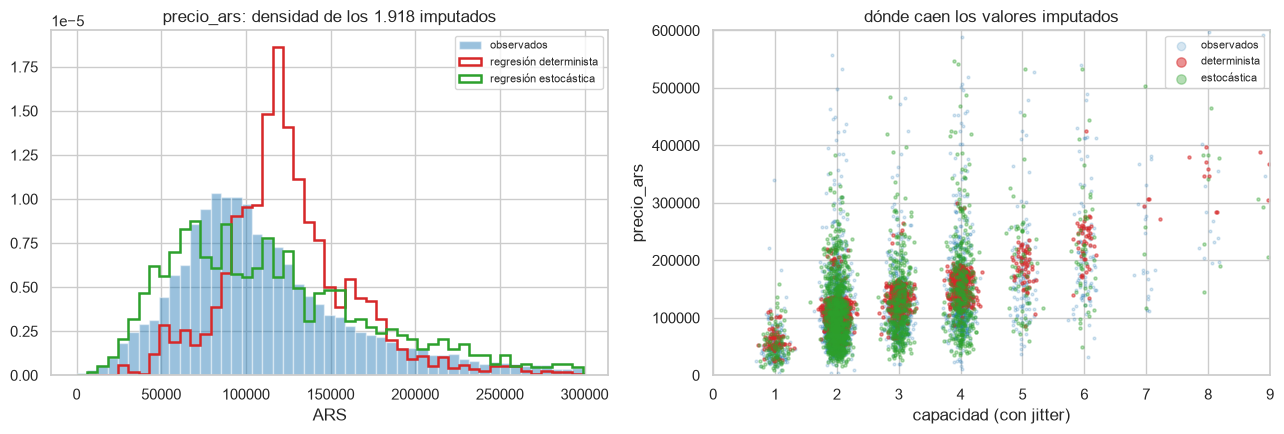

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
rng_jit = np.random.default_rng(SEMILLA)
mr = MASCARA.precio_ars

b = np.linspace(0, alq.precio_ars.quantile(.95), 50)
axes[0].hist(alq.precio_ars.dropna(), bins=b, density=True, color="tab:blue", alpha=.45, label="observados")
axes[0].hist(alq_reg.loc[mr, "precio_ars"], bins=b, density=True, histtype="step", lw=1.8, color="tab:red", label="regresión determinista")
axes[0].hist(alq_reg_est.loc[mr, "precio_ars"], bins=b, density=True, histtype="step", lw=1.8, color="tab:green", label="regresión estocástica")
axes[0].set_title("precio_ars: densidad de los 1.918 imputados")
axes[0].set_xlabel("ARS"); axes[0].legend(fontsize=8)

# Contra capacidad, que es el predictor más fuerte. Le agrego jitter horizontal porque es
# discreta y si no los puntos se apilan en una línea vertical y no se ve nada.
jit = lambda n: rng_jit.normal(0, .10, n)
sub = alq[tiene_precio].sample(3000, random_state=SEMILLA)
axes[1].scatter(sub.capacidad + jit(len(sub)), sub.precio_ars, s=4, alpha=.18, color="tab:blue", label="observados")
axes[1].scatter(alq.capacidad[mr] + jit(mr.sum()), alq_reg.loc[mr, "precio_ars"], s=5, alpha=.5, color="tab:red", label="determinista")
axes[1].scatter(alq.capacidad[mr] + jit(mr.sum()), alq_reg_est.loc[mr, "precio_ars"], s=5, alpha=.35, color="tab:green", label="estocástica")
axes[1].set_ylim(0, 600_000); axes[1].set_xlim(0, 9)
axes[1].set_xlabel("capacidad (con jitter)"); axes[1].set_ylabel("precio_ars")
axes[1].set_title("dónde caen los valores imputados")
axes[1].legend(fontsize=8, markerscale=3)

plt.tight_layout()
plt.show()

**La especificación.** Modelo el **log** de `precio_ars`, no el precio. Con asimetría 4,86 el
ajuste sobre la escala cruda da peor R² (0,277 contra 0,342 con los mismos predictores) y
además predice precios negativos en 9 de los 1.918 faltantes. Un alquiler de precio negativo
no es una mala estimación, es un valor imposible.

Los predictores son las cinco variables completas más `tipo_habitacion` y `barrio` como
indicadoras, 55 columnas en total. Probé agregar `tipo_propiedad`: subía el R² de 0,371 a
0,386 a costa de 56 columnas más, así que lo dejé afuera.

El R² validado cruzado da **0,371**, contra 0,391 in-sample. Reporto el primero, que es el
honesto. El desvío de los residuos en log es 0,474.

**La corrección al volver a pesos.** `exp()` de la predicción del log devuelve la mediana
condicional, no la media, así que subestima. Aplico el factor de smearing de Duan, que es el
promedio de `exp(residuos)` y me dio **1,1363**. Sin corregir, la media de los precios
imputados daría $112.949; corregida da $128.344, contra $131.372 de los observados.

**Determinista contra estocástica.** Acá está el punto.

El modelo explica el 37 % de la variación del log del precio. El 63 % restante es residuo.
La imputación determinista devuelve solo la parte explicada y tira el resto: cada faltante
recibe la predicción exacta, sin ruido. La estocástica le suma un residuo sorteado con el
desvío de los residuos reales.

El efecto sobre la dispersión de los 1.918 valores imputados:

| | desvío |
| --- | ---: |
| observados | 115.303 |
| regresión determinista | **46.561** |
| regresión estocástica | **78.476** |

Mismo modelo, mismos avisos, y la determinista produce menos de la mitad de dispersión que
la estocástica.

En el gráfico de la derecha se ve qué significa eso geométricamente. Los puntos rojos forman
bandas horizontales apretadas dentro de cada capacidad: están todos sobre el plano de
regresión, que es una superficie de dimensión mucho menor que la nube de datos. Los verdes
se mezclan con los observados.

Es el mismo problema de 5b con mejor disfraz. La imputación por la mediana apilaba todo en
un punto y se veía a la legua. La regresión determinista apila todo sobre una recta, y como
la recta tiene pendiente el resultado parece razonable. Pero los valores imputados quedan
perfectamente predecibles a partir de los predictores, y eso infla cualquier correlación que
calcule después. Justo lo que voy a necesitar sano para el PCA del ejercicio 6.

Una salvedad sobre la comparación: los 115.303 de los observados no son la meta exacta.
En 5a vi que el precio falta sobre todo en los avisos de poca actividad, así que los que
faltan no son una muestra al azar y no tendrían por qué tener la misma dispersión que el
resto. Lo que sí es comparación limpia es 46.561 contra 78.476, porque son los mismos 1.918
avisos con el mismo modelo.

**MICE produce valores imposibles.** Converge en 7 iteraciones, pero trabaja sobre la escala
cruda de cada variable, sin transformación y sin restricción de dominio. El resultado:
39 precios negativos, con un mínimo de **-414.370**, más 3 camas negativas, 4 dormitorios en
cero o menos y un `minimo_noches` de -7,69. Y el 100 % de los valores que imputa no son
enteros, en las seis variables.

Mi regresión no tiene ese problema por una razón concreta: como el modelo está en log, el
valor que devuelve es `exp()` de algo, y eso es siempre positivo. La restricción de dominio
está metida en la transformación, no agregada después.

Se podría arreglar pasándole a MICE las variables ya transformadas o recortando la salida,
pero tal como sale del módulo hay que revisarla antes de usarla. En dispersión queda en el
medio, 64.146, entre mis dos versiones.

**Con cuál me quedo.** Con la estocástica. La determinista es mejor si lo único que me
importa es minimizar el error de cada predicción, pero acá no estoy prediciendo: estoy
completando un dataset que después voy a analizar. Un dataset donde 1.918 filas caen exactas
sobre un plano no sirve para eso.

### 5f. Comparación de los métodos

> Analice los resultados encontrados a partir de la aplicación de los métodos anteriores.
> Compare los mismos realizando gráficos sobre los valores resultantes en cada caso.

Los faltantes de este dataset son reales, así que no tengo el valor verdadero contra el cual
medir. Para poder comparar con números y no solo con histogramas superpuestos, armo un
experimento: tomo los avisos que sí tienen precio, le borro el dato a una parte con una
máscara que yo conozco, imputo con los seis métodos y comparo contra lo que había.

In [29]:
# La máscara no la sorteo uniforme. En 5a vi que el faltante de precio_ars NO es MCAR: la
# tasa baja con la actividad del aviso. Si borrara al azar estaría simulando un mecanismo
# que yo mismo descarté, así que uso como probabilidad de borrado la tasa real de cada tramo.
tramos_act = pd.cut(alq.cantidad_resenias, [-1, 0, 5, 20, 100, np.inf],
                    labels=["0", "1-5", "6-20", "21-100", "100+"])
tasa_real = alq.groupby(tramos_act, observed=True).precio_ars.apply(lambda s: s.isna().mean())

print("tasa real de faltantes de precio por tramo de actividad:")
print(tasa_real.round(3).to_string())

rng_exp = np.random.default_rng(SEMILLA)
probabilidad = tramos_act.map(tasa_real).astype(float).to_numpy()
observado = alq.precio_ars.notna().to_numpy()

# Borro sólo donde HAY dato, para tener contra qué comparar. Los 1.918 faltantes originales
# siguen faltando: simplemente no los evalúo.
borrar = observado & (rng_exp.random(len(alq)) < probabilidad)
verdad = alq.precio_ars[borrar]

alq_exp = alq.copy()
alq_exp.loc[borrar, "precio_ars"] = np.nan

print(f"\navisos con precio observado: {observado.sum():,}")
print(f"borrados para el experimento: {borrar.sum():,} ({100 * borrar.sum() / observado.sum():.2f} %)")
print("\ntasa de borrado lograda por tramo:")
print(pd.Series(borrar).groupby(tramos_act, observed=True).mean().round(3).to_string())

tasa real de faltantes de precio por tramo de actividad:
cantidad_resenias
0         0.103
1-5       0.073
6-20      0.064
21-100    0.058
100+      0.038

avisos con precio observado: 27,520
borrados para el experimento: 1,802 (6.55 %)

tasa de borrado lograda por tramo:
cantidad_resenias
0         0.096
1-5       0.062
6-20      0.061
21-100    0.055
100+      0.043


In [30]:
def imputar_precio(d, semilla=SEMILLA):
    """Aplica los siete métodos a precio_ars y devuelve la columna completa de cada uno.

    Reusa ESTRATO, Z y X_reg tal como están: los tres se construyeron sólo con columnas
    completas, así que valen igual para el dataset agujereado (mismas filas, mismo índice).
    """
    res = {}
    falta = d.precio_ars.isna()

    res["mediana"] = d.precio_ars.fillna(d.precio_ars.median())
    res["hot deck estratos"] = hot_deck(d, ["precio_ars"], ESTRATO, semilla)[0].precio_ars
    res["hot deck similitud"] = hot_deck_similitud(d, ["precio_ars"], Z, d.tipo_habitacion, 5, semilla)[0].precio_ars

    sc = StandardScaler()
    Y = sc.inverse_transform(KNNImputer(n_neighbors=5, weights="distance").fit_transform(sc.fit_transform(d[NUM])))
    res["KNN"] = pd.DataFrame(Y, columns=NUM, index=d.index).precio_ars

    ok = ~falta
    ylog = np.log(d.precio_ars)
    mod = LinearRegression().fit(X_reg[ok], ylog[ok])
    r = ylog[ok] - mod.predict(X_reg[ok])
    pl = mod.predict(X_reg[falta])

    det = d.precio_ars.copy()
    det[falta] = np.exp(pl) * np.mean(np.exp(r))
    res["regresión determinista"] = det

    rg = np.random.default_rng(semilla)
    est = d.precio_ars.copy()
    est[falta] = np.exp(pl + rg.normal(0, r.std(), int(falta.sum())))
    res["regresión estocástica"] = est

    sc2 = StandardScaler()
    Y2 = sc2.inverse_transform(IterativeImputer(max_iter=20, random_state=semilla).fit_transform(sc2.fit_transform(d[NUM])))
    res["MICE"] = pd.DataFrame(Y2, columns=NUM, index=d.index).precio_ars

    return res


imp_exp = imputar_precio(alq_exp)
print("listo")

listo


In [31]:
filas = []
for n, s in imp_exp.items():
    pred = s[borrar]
    filas.append({
        "método": n,
        "MAE": (pred - verdad).abs().mean(),
        "RMSE": np.sqrt(((pred - verdad) ** 2).mean()),
        "error mediano %": (100 * ((pred - verdad).abs() / verdad)).median(),
        # La mediana imputa una constante, así que su correlación con el real no está
        # definida: el desvío del predictor es cero.
        "corr con el real": np.nan if pred.std() == 0 else np.corrcoef(pred, verdad)[0, 1],
        "desvio imputados": pred.std(),
    })

errores = pd.DataFrame(filas).set_index("método").sort_values("RMSE")
errores.loc["(valor real)"] = [0, 0, 0, 1.0, verdad.std()]
errores.round(3)

,MAE,RMSE,error mediano %,corr con el real,desvio imputados
método,,,,,
MICE,52083.530,97619.722,30.658,0.533,62582.969
KNN,50485.255,98904.291,26.999,0.532,76529.142
regresión determinista,49997.926,100257.997,29.611,0.530,83096.158
mediana,59742.759,118948.188,32.781,NaN,0.000
regresión estocástica,70957.604,123074.197,40.756,0.379,104802.913
hot deck similitud,63864.285,123475.921,32.931,0.378,105359.041
hot deck estratos,74574.195,138763.529,40.216,0.262,112837.661
(valor real),0.000,0.000,0.000,1.000,115387.240


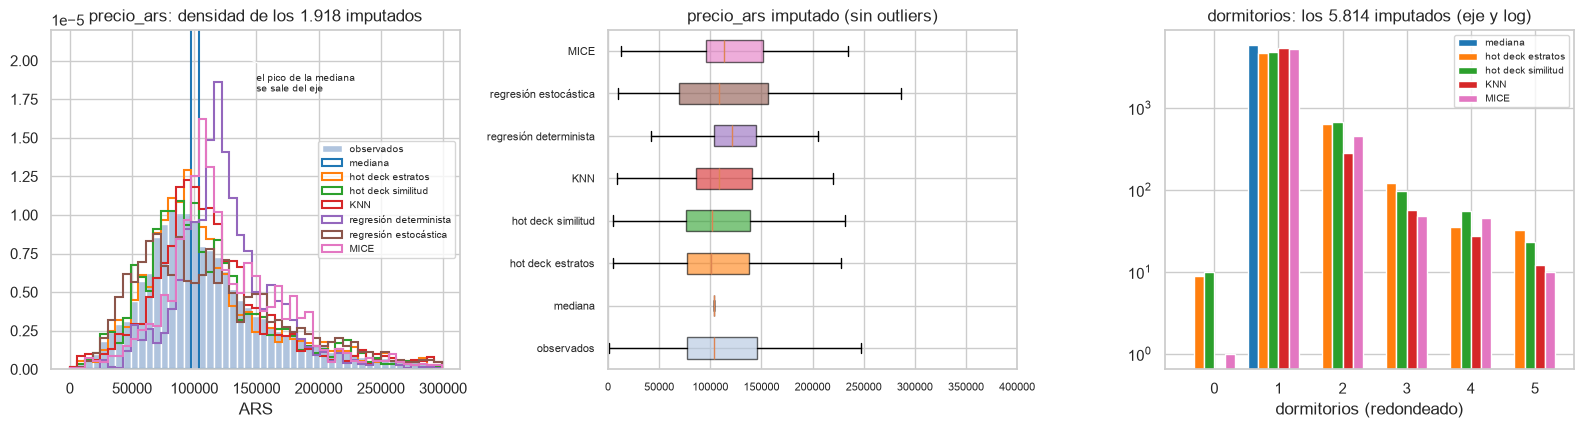

In [32]:
METODOS = {
    "mediana": alq_mediana, "hot deck estratos": alq_hotdeck, "hot deck similitud": alq_hd_sim,
    "KNN": alq_knn, "regresión determinista": alq_reg,
    "regresión estocástica": alq_reg_est, "MICE": alq_mice,
}
col = dict(zip(METODOS, plt.cm.tab10.colors))
mp = MASCARA.precio_ars

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

b = np.linspace(0, alq.precio_ars.quantile(.95), 50)
axes[0].hist(alq.precio_ars.dropna(), bins=b, density=True, color="lightsteelblue", label="observados")
for n, d in METODOS.items():
    axes[0].hist(d.loc[mp, "precio_ars"], bins=b, density=True, histtype="step", lw=1.5, color=col[n], label=n)
# Sin este recorte el pico de la mediana aplasta las otras seis curvas y no se ve nada.
axes[0].set_ylim(0, 2.2e-5)
axes[0].annotate("el pico de la mediana\nse sale del eje", xy=(103206, 2.15e-5), xytext=(150000, 1.8e-5),
                 fontsize=7, arrowprops=dict(arrowstyle="->", lw=.8))
axes[0].set_title("precio_ars: densidad de los 1.918 imputados"); axes[0].set_xlabel("ARS"); axes[0].legend(fontsize=7)

datos = [alq.precio_ars.dropna()] + [d.loc[mp, "precio_ars"] for d in METODOS.values()]
bp = axes[1].boxplot(datos, tick_labels=["observados"] + list(METODOS),
                     orientation="horizontal", showfliers=False, patch_artist=True)
for p, c in zip(bp["boxes"], ["lightsteelblue"] + [col[n] for n in METODOS]):
    p.set_facecolor(c); p.set_alpha(.6)
axes[1].set_xlim(0, 400_000); axes[1].set_title("precio_ars imputado (sin outliers)"); axes[1].tick_params(labelsize=8)

# Las dos regresiones sólo tocaron precio_ars, así que en dormitorios no tienen valores propios.
md = MASCARA.dormitorios
disc = {k: v for k, v in METODOS.items() if not k.startswith("regresión")}
orden = [0, 1, 2, 3, 4, 5]; x = np.arange(len(orden)); w = .8 / len(disc)
for k, (n, d) in enumerate(disc.items()):
    alturas = [int(((d.loc[md, "dormitorios"] >= v - .5) & (d.loc[md, "dormitorios"] < v + .5)).sum())
               for v in orden]
    axes[2].bar(x + (k - len(disc) / 2) * w, alturas, width=w, color=col[n], label=n)
axes[2].set_xticks(x, orden); axes[2].set_yscale("log")
axes[2].set_xlabel("dormitorios (redondeado)")
axes[2].set_title("dormitorios: los 5.814 imputados (eje y log)"); axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [33]:
# La consecuencia práctica: qué le hace cada método a las relaciones entre variables.
# Importa para el ejercicio 6, que calcula PCA sobre la matriz de covarianzas.
pares = ["capacidad", "camas", "dormitorios", "noches_ocupadas_anio"]

tabla = {"solo filas completas": alq.dropna(subset=["precio_ars"] + pares)[["precio_ars"] + pares].corr().precio_ars[pares]}
for n, d in METODOS.items():
    tabla[n] = d[["precio_ars"] + pares].corr().precio_ars[pares]

pd.DataFrame(tabla).T.round(3)

,capacidad,camas,dormitorios,noches_ocupadas_anio
solo filas completas,0.512,0.396,0.399,-0.065
mediana,0.495,0.384,0.379,-0.049
hot deck estratos,0.498,0.381,0.232,-0.052
hot deck similitud,0.504,0.385,0.275,-0.054
KNN,0.506,0.393,0.369,-0.057
regresión determinista,0.510,0.389,0.396,-0.055
regresión estocástica,0.505,0.388,0.391,-0.054
MICE,0.512,0.402,0.378,-0.058


Los faltantes de este dataset son reales, así que no hay valor verdadero contra el cual
medir. Para tener números armé un experimento: sobre los 27.520 avisos que sí tienen precio,
borré 1.802 (6,55 %) con una máscara que conozco, imputé con los siete métodos y comparé.

La máscara no es al azar. Uso como probabilidad de borrado la tasa real de faltantes de cada
tramo de actividad, porque en 5a concluí que este faltante no es MCAR. Las tasas logradas
(0,096 / 0,062 / 0,061 / 0,055 / 0,043) siguen a las reales (0,103 / 0,073 / 0,064 / 0,058 /
0,038).

**El resultado principal es que las dos columnas que importan están invertidas.**

| método | RMSE | desvío de los imputados |
| --- | ---: | ---: |
| MICE | 97.620 | 62.583 |
| KNN | 98.904 | 76.529 |
| regresión determinista | 100.258 | 83.096 |
| mediana | 118.948 | 0 |
| regresión estocástica | 123.074 | 104.803 |
| hot deck similitud | 123.476 | 105.359 |
| hot deck estratos | 138.764 | 112.838 |
| *valor real* | 0 | 115.387 |

Los tres que menos se equivocan son los tres que promedian, y son los que menos dispersión
producen. Los tres que más se equivocan son los que copian un valor real o le suman ruido, y
son los que mejor reproducen el desvío de 115.387. No es casualidad: promediar acerca cada
predicción al centro, y acercarse al centro es exactamente lo que minimiza el error
cuadrático. La dispersión es el precio de esa cercanía.

**Por eso el RMSE no alcanza para elegir.** La mediana tiene mejor RMSE (118.948) que la
regresión estocástica (123.074) y que los dos hot deck, y su desvío es **cero**: imputa
1.802 veces el mismo número. El RMSE mide qué tan cerca está cada valor de su verdadero, que
es la pregunta de un problema de predicción. Acá el problema es otro: quiero un dataset que
se parezca al que habría tenido si no faltara nada. Son dos objetivos distintos y ningún
método gana en los dos.

Lo mismo se ve en la correlación con el valor real: la regresión determinista da 0,530 y la
estocástica 0,379. El ruido que le agregué empeora las dos métricas puntuales, y es a
propósito.

En los gráficos se ve lo mismo de tres formas. En la densidad, la mediana es un pico que se
sale del eje y la regresión determinista una campana angosta centrada en 120.000, mientras
el hot deck y la estocástica siguen la forma ancha de los observados. En el boxplot, la caja
de la mediana es una raya y la de la estocástica es la única comparable a la de los
observados. Y en `dormitorios` se ve la otra diferencia: hot deck y mediana usan solo valores
enteros, KNN y MICE llenan los huecos entre ellos.

**El efecto sobre las correlaciones es menor de lo que esperaba.** En `precio_ars` casi no se
mueve nada: 0,512 con `capacidad` en las filas completas, y entre 0,495 y 0,512 según el
método. La explicación es simple: solo el 6,5 % de la columna está imputado, así que el
94 % de las filas manda igual en cualquier caso.

Donde sí se ve algo es en `dormitorios`, que tiene el 19,75 % imputado. Ahí el hot deck por
estratos baja `corr(precio, dormitorios)` de 0,399 a **0,232**, y el de similitud a 0,275.
Es la misma cosa que encontré en 5c: esos métodos copian valores de hostels con veinte o
treinta dormitorios a avisos que son habitaciones baratas, y esos pares rompen la relación
entre precio y tamaño. La correlación no se infla, se diluye.

**Con qué me quedo.** No hay un ganador único y la elección depende de para qué sigue el
dataset.

- Si lo que necesito es el mejor valor posible en cada celda, **KNN o MICE**.
- Si necesito que el dataset conserve su variabilidad, que es mi caso porque el ejercicio 6
  es un PCA sobre la matriz de covarianzas, **la regresión estocástica** para `precio_ars`.
- Para las variables de conteo, **el hot deck**, porque es el único que devuelve valores que
  existen: KNN y MICE imputan 2,4 camas y 1,19 dormitorios.
- Para `puntaje_resenias`, **ninguno**. Es un faltante estructural y todos los métodos le
  inventan una calificación a un aviso que nunca fue calificado.

**Límites de esta comparación.** El experimento es una sola corrida con una sola semilla, y
solo sobre `precio_ars`. La máscara reproduce el gradiente de actividad que observé, pero no
el mecanismo real, que no conozco. Y el ranking que da vale para esta máscara: con un borrado
al azar los métodos que promedian sacarían todavía más ventaja, porque el faltante quedaría
repartido parejo y habría más información cerca de cada celda vacía.

## Ejercicio 6. Análisis de Componentes Principales

> Cargue el dataset *vehiculos.csv* y conteste las siguientes consignas.

### 6a. Matriz de covarianzas

> Calcule la matriz de covarianzas. ¿Qué nos indica la misma sobre los atributos del dataset?

In [34]:
# Primero miro qué tengo: tamaño, tipos y faltantes. Todavía no decido nada.
vehiculos = pd.read_csv("data/vehiculos.csv")

print(f"dimensiones: {vehiculos.shape[0]} filas x {vehiculos.shape[1]} columnas\n")
display(vehiculos.dtypes.to_frame("tipo").T)
display(vehiculos.isna().sum().to_frame("faltantes").T)
vehiculos.head()

dimensiones: 2809 filas x 17 columnas



,marca,modelo,anio,clase,traccion,combustible,transmision,cilindros,cilindrada,mpg_ciudad,mpg_ruta,mpg_combinado,co2_g_milla,barriles_anio,costo_combustible_anio,puntaje_gei,ahorro_5anios
tipo,str,str,int64,str,str,str,str,float64,float64,int64,int64,int64,float64,float64,int64,int64,int64


,marca,modelo,anio,clase,traccion,combustible,transmision,cilindros,cilindrada,mpg_ciudad,mpg_ruta,mpg_combinado,co2_g_milla,barriles_anio,costo_combustible_anio,puntaje_gei,ahorro_5anios
faltantes,0,0,0,0,0,0,0,12,12,0,0,0,0,0,0,0,0


,marca,modelo,anio,clase,traccion,combustible,transmision,cilindros,cilindrada,mpg_ciudad,mpg_ruta,mpg_combinado,co2_g_milla,barriles_anio,costo_combustible_anio,puntaje_gei,ahorro_5anios
0,Jaguar,F-Type R AWD Coupe,2024,Two Seaters,All-Wheel Drive,Premium,Automatic (S8),8.0,5.0,16,24,18,481.0,16.528,4200,4,-10000
1,Jaguar,F-Type R AWD Convertible,2024,Two Seaters,All-Wheel Drive,Premium,Automatic (S8),8.0,5.0,16,24,18,481.0,16.528,4200,4,-10000
2,Jaguar,F-Type P450 RWD Coupe,2024,Two Seaters,Rear-Wheel Drive,Premium,Automatic (S8),8.0,5.0,17,24,19,460.0,15.658,4000,4,-9000
3,Jaguar,F-Type P450 RWD Convertible,2024,Two Seaters,Rear-Wheel Drive,Premium,Automatic (S8),8.0,5.0,17,24,19,460.0,15.658,4000,4,-9000
4,Jaguar,F-Type P450 AWD R-Dynamic Coupe,2024,Two Seaters,All-Wheel Drive,Premium,Automatic (S8),8.0,5.0,16,24,18,481.0,16.528,4200,4,-10000


In [35]:
# Los faltantes de cilindros y cilindrada caen en las mismas filas. Miro quiénes son
# antes de decidir si imputo o descarto: el criterio del ejercicio 5 fue no imputar
# lo que en realidad no aplica.
sin_motor = vehiculos["cilindros"].isna()

print(f"filas con cilindros/cilindrada faltante: {sin_motor.sum()}")
display(vehiculos.loc[sin_motor, ["marca", "modelo", "combustible", "co2_g_milla",
                                  "costo_combustible_anio", "puntaje_gei"]])

# Los ceros de co2 y costo no son ceros medidos: chequeo si coinciden con esas filas.
ceros = (vehiculos["co2_g_milla"] == 0) | (vehiculos["costo_combustible_anio"] == 0)
print(f"ceros en co2_g_milla / costo_combustible_anio: {ceros.sum()}")
print(f"¿son exactamente las mismas filas?: {(ceros == sin_motor).all()}")
print(f"puntaje_gei fuera del rango válido 1-10: {(~vehiculos['puntaje_gei'].between(1, 10)).sum()}")
print(f"filas duplicadas exactas: {vehiculos.duplicated().sum()}")

filas con cilindros/cilindrada faltante: 12


,marca,modelo,combustible,co2_g_milla,costo_combustible_anio,puntaje_gei
1679,Hyundai,Nexo,Hydrogen,0.0,0,10
1680,Hyundai,Nexo Blue,Hydrogen,0.0,0,10
1681,Toyota,Mirai Limited,Hydrogen,0.0,0,10
1682,Toyota,Mirai XLE,Hydrogen,0.0,0,10
1938,Toyota,Mirai XLE,Hydrogen,0.0,0,10
1939,Hyundai,Nexo,Hydrogen,0.0,0,10
1940,Hyundai,Nexo Blue,Hydrogen,0.0,0,10
2773,Hyundai,Nexo,Hydrogen,0.0,0,10
2774,Hyundai,Nexo Blue,Hydrogen,0.0,0,10
2775,Honda,CR-V e-FCEV,Electricity and Hydrogen,0.0,0,-1


ceros en co2_g_milla / costo_combustible_anio: 12
¿son exactamente las mismas filas?: True
puntaje_gei fuera del rango válido 1-10: 1
filas duplicadas exactas: 2


In [36]:
# Diez variables numéricas. Dejo afuera anio: tiene tres valores y es una etiqueta
# del modelo, no una magnitud del vehículo. Dejo adentro las derivadas
# (barriles_anio, puntaje_gei, ahorro_5anios) a propósito: si podo la redundancia
# a mano, el PCA de 6b a 6f se queda sin nada que descubrir.
NUM = ["cilindros", "cilindrada", "mpg_ciudad", "mpg_ruta", "mpg_combinado",
       "co2_g_milla", "barriles_anio", "costo_combustible_anio",
       "puntaje_gei", "ahorro_5anios"]

# Descarto las filas de hidrógeno y los duplicados exactos en un solo paso.
veh = vehiculos.loc[~sin_motor].drop_duplicates().reset_index(drop=True)
X = veh[NUM]

print(f"{vehiculos.shape[0]} -> {veh.shape[0]} filas ({vehiculos.shape[0] - veh.shape[0]} descartadas)")
print(f"matriz de trabajo: {X.shape[0]} x {X.shape[1]}, faltantes: {int(X.isna().sum().sum())}")

2809 -> 2795 filas (14 descartadas)
matriz de trabajo: 2795 x 10, faltantes: 0


In [37]:
# Antes de mirar la covarianza necesito ver en qué unidades está cada variable.
# Sin esto la matriz del paso siguiente no se puede interpretar.
resumen = pd.DataFrame({
    "media": X.mean(),
    "desvío": X.std(),
    "varianza": X.var(),
    "mín": X.min(),
    "máx": X.max(),
}).sort_values("varianza", ascending=False)

display(resumen.round(2))
print(f"razón entre la varianza mayor y la menor: {resumen['varianza'].max() / resumen['varianza'].min():,.0f}")

,media,desvío,varianza,mín,máx
ahorro_5anios,-4628.80,4870.34,23720251.07,-31250.00,7250.00
costo_combustible_anio,3169.27,962.87,927124.19,1100.00,8450.00
co2_g_milla,394.98,113.01,12770.42,50.00,979.00
mpg_ciudad,21.66,7.51,56.47,8.00,57.00
mpg_combinado,23.73,7.05,49.68,9.00,57.00
mpg_ruta,27.18,6.74,45.42,11.00,58.00
barriles_anio,13.25,3.81,14.53,1.72,33.06
cilindros,5.39,1.75,3.08,3.00,16.00
puntaje_gei,4.72,1.49,2.21,1.00,10.00
cilindrada,2.99,1.19,1.43,1.20,8.00


razón entre la varianza mayor y la menor: 16,643,561


In [38]:
# Ésta es la matriz que pide la consigna, sobre las variables en sus unidades originales.
cov = X.cov()
cov.round(1)

,cilindros,cilindrada,mpg_ciudad,mpg_ruta,mpg_combinado,co2_g_milla,barriles_anio,costo_combustible_anio,puntaje_gei,ahorro_5anios
cilindros,3.1,1.9,-7.9,-7.5,-7.8,137.8,4.7,1320.8,-1.6,-6457.9
cilindrada,1.9,1.4,-5.4,-5.2,-5.4,97.2,3.3,856.2,-1.2,-4258.8
mpg_ciudad,-7.9,-5.4,56.5,45.7,52.2,-703.7,-23.6,-6064.5,9.2,30342.7
mpg_ruta,-7.5,-5.2,45.7,45.4,45.5,-642.0,-21.5,-5530.0,8.1,27128.6
mpg_combinado,-7.8,-5.4,52.2,45.5,49.7,-681.8,-22.9,-5898.3,8.8,29311.1
co2_g_milla,137.8,97.2,-703.7,-642.0,-681.8,12770.4,428.9,93055.6,-162.4,-510174.2
barriles_anio,4.7,3.3,-23.6,-21.5,-22.9,428.9,14.5,3141.4,-5.5,-17259.5
costo_combustible_anio,1320.8,856.2,-6064.5,-5530.0,-5898.3,93055.6,3141.4,927124.2,-1153.0,-4557624.0
puntaje_gei,-1.6,-1.2,9.2,8.1,8.8,-162.4,-5.5,-1153.0,2.2,6441.4
ahorro_5anios,-6457.9,-4258.8,30342.7,27128.6,29311.1,-510174.2,-17259.5,-4557624.0,6441.4,23720251.1


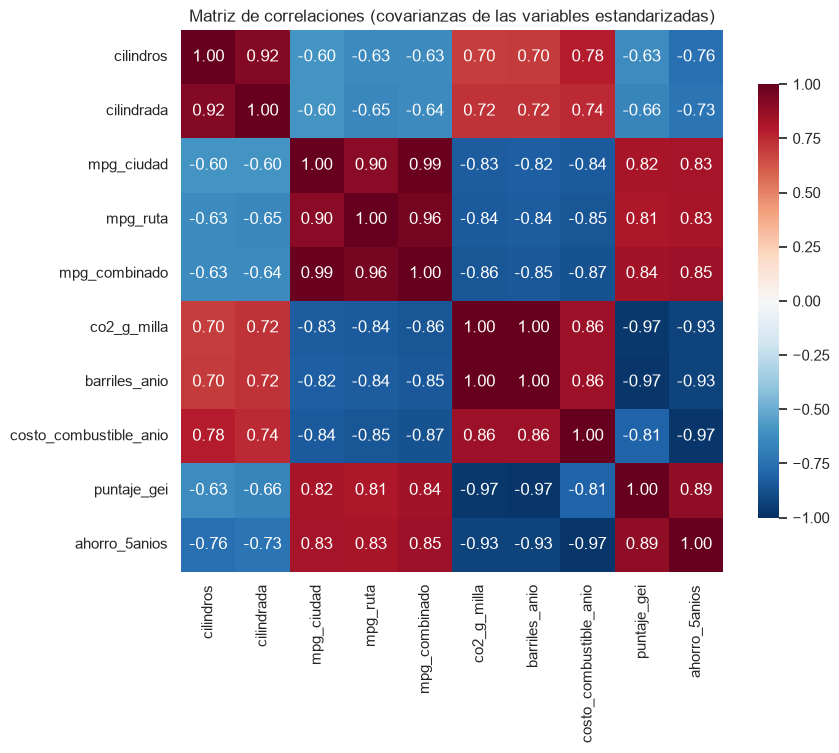

co2_g_milla             barriles_anio    0.996
mpg_ciudad              mpg_combinado    0.986
costo_combustible_anio  ahorro_5anios   -0.972
barriles_anio           puntaje_gei     -0.969
co2_g_milla             puntaje_gei     -0.967
mpg_ruta                mpg_combinado    0.958
barriles_anio           ahorro_5anios   -0.930
co2_g_milla             ahorro_5anios   -0.927
dtype: float64

In [39]:
# Estandarizar y después calcular covarianzas da la matriz de correlación.
# Es la misma información que la celda anterior, pero en una escala común de -1 a 1.
correl = X.corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(correl, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            square=True, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Matriz de correlaciones (covarianzas de las variables estandarizadas)")
plt.tight_layout()
plt.show()

# Los pares más fuertes: ahí está la redundancia que el PCA va a comprimir.
pares = correl.where(np.triu(np.ones(correl.shape), k=1).astype(bool)).stack().dropna()
pares.sort_values(key=abs, ascending=False).head(8).round(3)

In [40]:
# Cuánto pesa cada variable en la varianza total cuando no estandarizo.
# La traza de la matriz de covarianzas es esa varianza total.
traza = np.trace(cov)
aporte = (pd.Series(np.diag(cov), index=NUM) / traza * 100).sort_values(ascending=False)

print(f"traza de la matriz de covarianzas: {traza:,.0f}")
print("aporte de cada variable a la varianza total, en % (sin estandarizar):")
print(aporte.round(3).to_string())

# Y del otro lado: qué tan débil es el par menos relacionado de la matriz de correlación.
fuera_diagonal = correl.mask(np.eye(len(NUM), dtype=bool)).abs()
print(f"\ncorrelación más débil de los 45 pares: {fuera_diagonal.min().min():.3f}")
print(f"pares con |r| > 0,90: {int((correl.abs().to_numpy()[np.triu_indices(len(NUM), k=1)] > .9).sum())} de 45")

traza de la matriz de covarianzas: 24,660,318
aporte de cada variable a la varianza total, en % (sin estandarizar):
ahorro_5anios             96.188
costo_combustible_anio     3.760
co2_g_milla                0.052
mpg_ciudad                 0.000
mpg_combinado              0.000
mpg_ruta                   0.000
barriles_anio              0.000
cilindros                  0.000
puntaje_gei                0.000
cilindrada                 0.000

correlación más débil de los 45 pares: 0.598
pares con |r| > 0,90: 10 de 45


Antes de calcular nada saqué 14 filas. Doce son vehículos de hidrógeno (Mirai, Nexo,
CR-V e-FCEV): no tienen cilindros ni cilindrada porque no tienen motor de combustión, y
además traen `co2_g_milla` y `costo_combustible_anio` en cero, que no son ceros medidos
sino huecos disfrazados, más un `puntaje_gei` de -1 que es un centinela. Imputarlos habría
sido inventarle un motor a un auto que no lo tiene, así que apliqué el mismo criterio del
5a: cuando el faltante es estructural no se imputa. Las otras dos filas son duplicados
exactos. Quedan 2.795 x 10. También dejé afuera `anio`, que tiene tres valores y es una
etiqueta del modelo, no una magnitud del vehículo.

**La matriz de covarianzas cruda no se puede interpretar.** El par `cilindros` con
`cilindrada` da 1,9 y el par `co2_g_milla` con `ahorro_5anios` da -510.174. Por esos
números parecería que el segundo par está cinco órdenes de magnitud más asociado que el
primero. En la matriz de correlación los mismos dos pares dan 0,92 y -0,927, o sea
prácticamente la misma fuerza. La diferencia estaba en las unidades, no en la relación:
una covarianza se mide en el producto de las unidades de las dos variables, y acá conviven
litros, millas por galón, gramos y dólares.

Lo mismo pasa en la diagonal, que son las varianzas. `ahorro_5anios` sola aporta el 96,2 %
de la varianza total y `costo_combustible_anio` otro 3,8 %. Las ocho variables restantes
suman menos de una décima de punto. Si corriera PCA directamente sobre esta matriz, la
primera componente sería `ahorro_5anios` disfrazada y me informaría más del 96 % de
varianza explicada sin haber descubierto nada. Por eso el 6b va sobre las variables
estandarizadas, que es lo mismo que hacer PCA sobre la matriz de correlación.

**Qué me dice la estructura, una vez en escala comparable.** Hay dos bloques de signo
opuesto. Por un lado el motor y lo que cuesta hacerlo andar: `cilindros`, `cilindrada`,
`co2_g_milla`, `barriles_anio` y `costo_combustible_anio`. Por el otro la eficiencia y lo
que se ahorra: `mpg_ciudad`, `mpg_ruta`, `mpg_combinado`, `puntaje_gei` y `ahorro_5anios`.
Dentro de cada bloque las correlaciones son positivas, entre bloques negativas. Es una
sola idea leída en dos direcciones: motor más grande, más consumo, más emisiones y más
gasto.

**Buena parte de esa redundancia es por construcción, no un hallazgo empírico.**
`co2_g_milla` y `barriles_anio` correlacionan 0,996 porque las dos se derivan del
rendimiento y del tipo de combustible con la misma fórmula de la EPA. `mpg_combinado` es
un promedio ponderado de `mpg_ciudad` y `mpg_ruta` (0,986 y 0,958). `puntaje_gei` es una
recodificación de las emisiones en una escala de 1 a 10 (-0,967 con `co2_g_milla`). Y
`ahorro_5anios` sale del costo anual proyectado (-0,972 con `costo_combustible_anio`).
Decidí dejar todas estas variables adentro igual: si las podaba a mano, el PCA de los
puntos siguientes no tendría nada que comprimir y la reducción la habría hecho yo, no el
método.

### 6b. Componentes principales y varianza explicada

> Realice ahora el análisis de componentes principales. ¿Cuánto explica de la variación
> total del dataset la primera componente? ¿Y si se incorpora la segunda? ¿Y el primer
> auto-valor?

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Control: en 6a predije, mirando la traza, que sin estandarizar la primera componente
# iba a ser ahorro_5anios disfrazada. Lo verifico antes de hacer el PCA en serio.
pca_crudo = PCA().fit(X)

print(f"CP1 sin estandarizar: {100 * pca_crudo.explained_variance_ratio_[0]:.2f} % de la varianza")
print("peso de cada variable en esa CP1 (las tres mayores):")
print(pd.Series(np.abs(pca_crudo.components_[0]), index=NUM)
      .sort_values(ascending=False).head(3).round(4).to_string())

CP1 sin estandarizar: 99.79 % de la varianza
peso de cada variable en esa CP1 (las tres mayores):
ahorro_5anios             0.9817
costo_combustible_anio    0.1890
co2_g_milla               0.0211


In [42]:
# Estandarizo y recién ahí calculo. Equivale a hacer PCA sobre la matriz de correlación.
Z = StandardScaler().fit_transform(X)
print(f"media ≈ 0: {Z.mean():.6f} | desvío ≈ 1: {Z.std():.6f}")

pca = PCA()          # sin n_components: calcula las diez
puntajes = pca.fit_transform(Z)

CP = [f"CP{i+1}" for i in range(pca.n_components_)]
scores = pd.DataFrame(puntajes, columns=CP, index=veh.index)
scores.head().round(3)

media ≈ 0: -0.000000 | desvío ≈ 1: 1.000000


,CP1,CP2,CP3,CP4,CP5,CP6,CP7,CP8,CP9,CP10
0,-2.941,1.239,0.235,0.086,0.208,-0.271,0.175,-0.086,0.095,-0.079
1,-2.941,1.239,0.235,0.086,0.208,-0.271,0.175,-0.086,0.095,-0.079
2,-2.579,1.336,0.300,-0.078,0.166,-0.209,0.004,-0.109,0.045,-0.049
3,-2.579,1.336,0.300,-0.078,0.166,-0.209,0.004,-0.109,0.045,-0.049
4,-2.941,1.239,0.235,0.086,0.208,-0.271,0.175,-0.086,0.095,-0.079


In [43]:
# El autovalor es la varianza de la componente. Como estandaricé, cada variable
# original aporta varianza 1, así que un autovalor se lee como "cuántas variables
# vale" esa componente. Ése es el criterio de Kaiser que uso en 6f.
resumen_pca = pd.DataFrame({
    "autovalor": pca.explained_variance_,
    "% varianza": 100 * pca.explained_variance_ratio_,
    "% acumulado": 100 * pca.explained_variance_ratio_.cumsum(),
}, index=CP)

display(resumen_pca.round(3))
print(f"suma de los autovalores: {pca.explained_variance_.sum():.4f}")
print(f"autovalores mayores a 1: {int((pca.explained_variance_ > 1).sum())}")

,autovalor,% varianza,% acumulado
CP1,8.313,83.098,83.098
CP2,0.827,8.271,91.369
CP3,0.426,4.260,95.629
CP4,0.221,2.211,97.840
CP5,0.104,1.041,98.881
CP6,0.068,0.681,99.562
CP7,0.032,0.322,99.884
CP8,0.006,0.059,99.943
CP9,0.004,0.043,99.985
CP10,0.001,0.015,100.000


suma de los autovalores: 10.0036
autovalores mayores a 1: 1


In [44]:
# Las componentes tienen que salir no correlacionadas entre sí. Si esto no da la
# identidad, el acumulado de la tabla anterior no se podría leer como suma directa.
scores[CP[:4]].corr().round(6)

,CP1,CP2,CP3,CP4
CP1,1.0,0.0,-0.0,0.0
CP2,0.0,1.0,0.0,0.0
CP3,-0.0,0.0,1.0,-0.0
CP4,0.0,0.0,-0.0,1.0


Primero corrí el PCA sin estandarizar, para comprobar lo que dije en 6a. Da 99,79 % en la
primera componente, con `ahorro_5anios` pesando 0,98 y todo lo demás casi en cero. No
descubrió nada, copió la variable de escala más grande. Con eso confirmado hago el PCA en
serio, sobre las variables estandarizadas.

Ya estandarizado, **la primera componente explica el 83,1 % de la variación total**.
Incorporando la segunda llego al **91,4 %**. Dos componentes de diez y me quedo con más del
noventa por ciento.

**El primer autovalor es 8,313.** Como estandaricé, cada variable original aporta 1 y los
diez autovalores suman 10 (me dio 10,0036, por una diferencia de divisor entre el
escalador y el PCA). Entonces ese número se lee directo: la primera componente sola vale
por más de ocho de las diez variables. La segunda vale 0,827, ni una variable entera. Entre
una y otra la caída es de un factor diez.

Esto es lo que esperaba después de 6a. Si ninguna correlación bajaba de 0,598, casi toda la
información tenía que concentrarse en un solo eje.

### 6c. Perfil de variación de las componentes

> Grafique el perfil de variación de las componentes en un gráfico de dispersión donde las
> X es la varianza y la Y el componente.

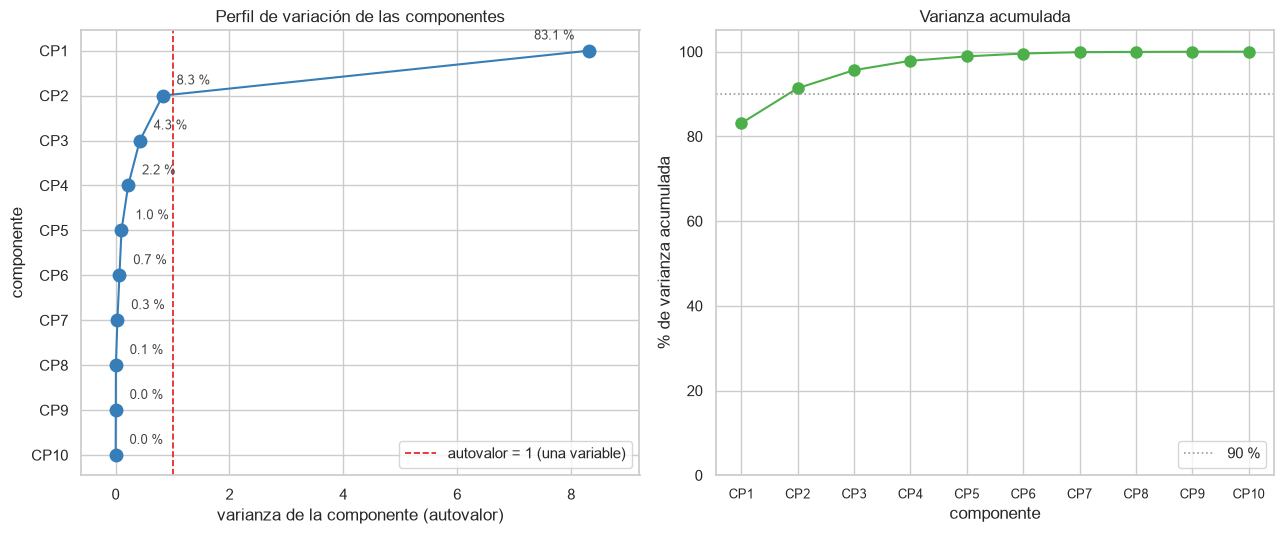

In [45]:
y = np.arange(1, len(CP) + 1)

fig, (izq, der) = plt.subplots(1, 2, figsize=(13, 5.5))

# La consigna pide la varianza en X y la componente en Y, así que el scree va horizontal,
# al revés de como se dibuja habitualmente.
izq.plot(resumen_pca["autovalor"], y, "o-", color="#377eb8", markersize=9, linewidth=1.5)
izq.axvline(1, color="#e41a1c", linestyle="--", linewidth=1.2,
            label="autovalor = 1 (una variable)")

for i, (av, pct) in enumerate(zip(resumen_pca["autovalor"], resumen_pca["% varianza"])):
    # La etiqueta de CP1 queda pegada al borde derecho, la mando para el otro lado.
    dx, ha = (-10, "right") if i == 0 else (10, "left")
    izq.annotate(f"{pct:.1f} %", (av, y[i]), textcoords="offset points",
                 xytext=(dx, 8), fontsize=9, color="#444", ha=ha)

izq.set_xlim(-0.6, 9.2)
izq.set_yticks(y)
izq.set_yticklabels(CP)
izq.invert_yaxis()                      # CP1 arriba, como se lee la tabla
izq.set_xlabel("varianza de la componente (autovalor)")
izq.set_ylabel("componente")
izq.set_title("Perfil de variación de las componentes")
izq.legend(loc="lower right")

# El acumulado no lo pide la consigna, pero es el gráfico con el que decido en 6f.
der.plot(y, resumen_pca["% acumulado"], "o-", color="#4daf4a", markersize=8, linewidth=1.5)
der.axhline(90, color="#999", linestyle=":", linewidth=1.2, label="90 %")
der.set_xticks(y)
der.set_xticklabels(CP, fontsize=9)
der.set_ylim(0, 105)
der.set_xlabel("componente")
der.set_ylabel("% de varianza acumulada")
der.set_title("Varianza acumulada")
der.legend(loc="lower right")

plt.tight_layout()
plt.show()

El perfil no baja en escalones parejos. Es un salto y después una meseta. CP1 está sola en
8,313 y CP2 ya cae a 0,827, diez veces menos. De ahí en adelante la línea se pone casi
vertical: las ocho componentes restantes están todas amontonadas contra el cero.

El codo, entonces, está en CP2. Es el último punto donde la línea todavía se mueve.

La línea roja marca el autovalor 1, que es lo que vale una variable original. Ocho de los
diez puntos quedan a la izquierda: esas componentes explican menos varianza que cualquiera
de las variables con las que arranqué, así que reemplazar variables por ellas no me ahorra
nada. CP2 queda en 0,827, apenas por debajo del corte. Ése es el caso dudoso y lo decido
en 6f.

El panel de la derecha muestra lo mismo desde el acumulado: con dos componentes ya paso el
90 %, con tres llego al 95,6 % y a partir de ahí la curva es plana.

### 6d. Matriz de loadings

> Analice la matriz de loading. ¿Qué información provee? ¿Qué variables están más
> correlacionadas con la primera componente?

In [46]:
# Los loadings salen de los autovectores reescalados por el desvío de cada componente.
# Como las variables están estandarizadas, cada loading se lee como la correlación entre
# la variable y la componente: va de -1 a 1.
loadings = pd.DataFrame(pca.components_.T * np.sqrt(pca.explained_variance_),
                        index=NUM, columns=CP)
loadings[CP[:4]].round(3)

,CP1,CP2,CP3,CP4
cilindros,-0.798,0.562,0.101,0.002
cilindrada,-0.802,0.543,0.054,-0.175
mpg_ciudad,0.907,0.279,-0.239,0.060
mpg_ruta,0.916,0.201,-0.235,0.093
mpg_combinado,0.935,0.248,-0.238,0.065
co2_g_milla,-0.958,-0.076,-0.254,-0.058
barriles_anio,-0.956,-0.070,-0.266,-0.048
costo_combustible_anio,-0.943,0.054,0.097,0.306
puntaje_gei,0.926,0.149,0.299,0.099
ahorro_5anios,0.960,-0.013,0.100,-0.254


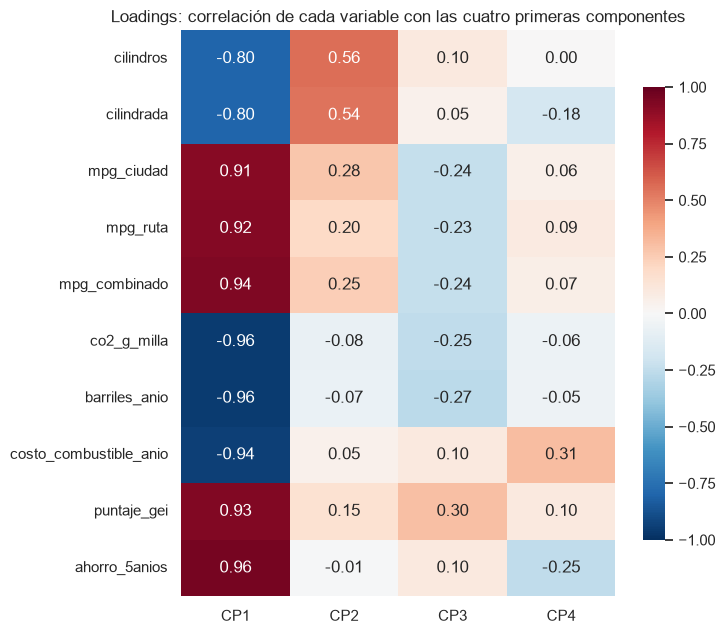

In [47]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(loadings[CP[:4]], cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True,
            fmt=".2f", cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Loadings: correlación de cada variable con las cuatro primeras componentes")
plt.tight_layout()
plt.show()

In [48]:
# Qué variables están más correlacionadas con CP1. Ordeno por valor absoluto porque
# el signo solo indica el sentido, no la fuerza. El cuadrado del loading es la
# proporción de la varianza de esa variable que CP1 se lleva.
orden = loadings["CP1"].abs().sort_values(ascending=False)
ranking_cp1 = pd.DataFrame({
    "loading en CP1": loadings.loc[orden.index, "CP1"],
    "|loading|": orden,
    "% de la variable que capta CP1": 100 * orden ** 2,
})
display(ranking_cp1.round(3))

# Leído por fila: cuánto de cada variable queda capturado si me quedo con 2 o con 3
# componentes. Es el número con el que decido en 6f.
comunalidad = pd.DataFrame({
    "con 2 CP": (loadings[CP[:2]] ** 2).sum(axis=1),
    "con 3 CP": (loadings[CP[:3]] ** 2).sum(axis=1),
}).sort_values("con 2 CP")
comunalidad.round(3)

,loading en CP1,|loading|,% de la variable que capta CP1
ahorro_5anios,0.960,0.960,92.073
co2_g_milla,-0.958,0.958,91.684
barriles_anio,-0.956,0.956,91.457
costo_combustible_anio,-0.943,0.943,88.848
mpg_combinado,0.935,0.935,87.493
puntaje_gei,0.926,0.926,85.685
mpg_ruta,0.916,0.916,83.824
mpg_ciudad,0.907,0.907,82.299
cilindrada,-0.802,0.802,64.273
cilindros,-0.798,0.798,63.639


,con 2 CP,con 3 CP
mpg_ruta,0.879,0.934
puntaje_gei,0.879,0.969
costo_combustible_anio,0.891,0.901
mpg_ciudad,0.901,0.958
barriles_anio,0.919,0.990
ahorro_5anios,0.921,0.931
co2_g_milla,0.923,0.987
mpg_combinado,0.936,0.993
cilindrada,0.938,0.941
cilindros,0.953,0.963


La matriz de loadings dice dos cosas según cómo la leas. Por columna, de qué está hecha
cada componente. Por fila, qué tan bien queda representada cada variable si me quedo con
esas componentes. Como estandaricé, cada loading es directamente la correlación entre la
variable y la componente, y su cuadrado es la parte de esa variable que la componente
capta.

**En CP1 cargan fuerte las diez variables**, todas entre 0,80 y 0,96 en valor absoluto.
Ninguna se queda afuera. Lo que las separa es el signo: negativo en `cilindros`,
`cilindrada`, `co2_g_milla`, `barriles_anio` y `costo_combustible_anio`, positivo en los
tres `mpg`, `puntaje_gei` y `ahorro_5anios`. Son los dos bloques que ya había visto en la
matriz de correlación del 6a. CP1 no es una variable disfrazada, es el contraste entre
auto grande que consume y auto chico que rinde. El signo en sí no importa, sklearn lo
elige por convención; lo que importa es que los bloques queden opuestos.

**Las más correlacionadas con CP1 son `ahorro_5anios` (0,960), `co2_g_milla` (-0,958),
`barriles_anio` (-0,956) y `costo_combustible_anio` (-0,943).** De cada una de esas cuatro,
CP1 se lleva cerca del 90 % de su varianza. Las que menos pegan son `cilindros` (-0,798) y
`cilindrada` (-0,802), con un 64 %.

Y ahí se entiende CP2: los únicos loadings que se despegan son `cilindros` (0,562) y
`cilindrada` (0,543), el resto anda por cero. CP2 es lo que el tamaño del motor tiene de
propio y no se explica por el consumo. Tiene sentido, dos autos con el mismo rendimiento
pueden llegar ahí con motores distintos.

Mirando por fila, con dos componentes la variable peor representada queda en 0,879, y con
tres ninguna baja de 0,90. No hay ninguna variable que se pierda al reducir.

### 6e. Biplot

> Genere un gráfico de biplot y explique brevemente qué información le provee el mismo.

In [49]:
# Para pintar los puntos necesito una categórica con pocos niveles. clase tiene 20,
# así que agrupo combustible en cuatro. Si CP1 es el eje eficiencia contra consumo,
# los híbridos enchufables tienen que caer de un lado solo.
def grupo_combustible(c):
    if "Electricity" in c:
        return "híbrido enchufable"
    if c == "Diesel":
        return "diésel"
    if "E85" in c:
        return "nafta o E85"
    return "nafta"

veh["grupo_comb"] = veh["combustible"].map(grupo_combustible)
veh["grupo_comb"].value_counts()

grupo_comb
nafta                 2594
híbrido enchufable     122
diésel                  56
nafta o E85             23
Name: count, dtype: int64

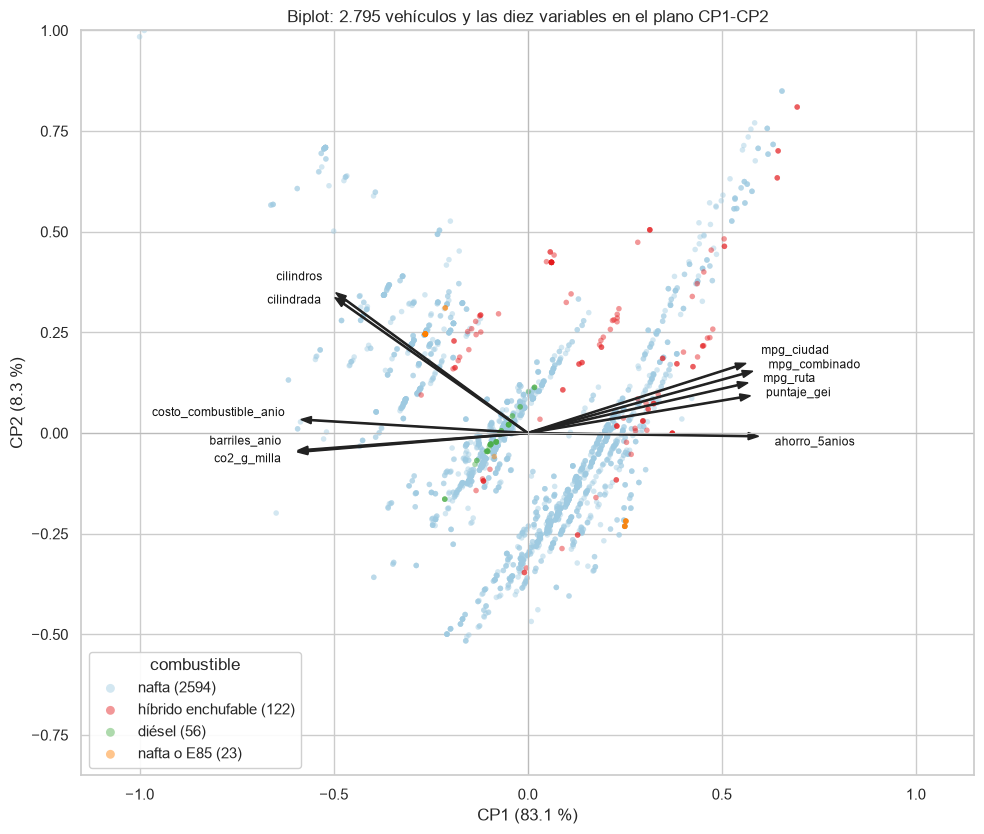

In [50]:
COLORES = {"nafta": "#9ecae1", "híbrido enchufable": "#e41a1c",
           "diésel": "#4daf4a", "nafta o E85": "#ff7f00"}

# Corrimientos manuales de las etiquetas. Hay tres pares de vectores casi superpuestos
# (co2 con barriles, cilindros con cilindrada, los tres mpg) y sin esto el texto choca.
NUDGE = {"cilindrada": (0, -.045), "barriles_anio": (0, .04), "mpg_ciudad": (0, .005),
         "mpg_combinado": (0, -.010), "mpg_ruta": (0, -.013), "puntaje_gei": (0, -.014)}


def biplot(scores, loadings, grupos, colores, ejes=("CP1", "CP2"), ax=None, escala=.62):
    """Biplot: observaciones como puntos y variables como vectores, en el mismo plano."""
    ex, ey = ejes
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 8.5))

    # Escalo los puntajes a [-1, 1] para que convivan con los loadings en un mismo eje.
    xs = scores[ex] / scores[ex].abs().max()
    ys = scores[ey] / scores[ey].abs().max()

    for g, color in colores.items():
        sel = (grupos == g).to_numpy()
        ax.scatter(xs[sel], ys[sel], c=color, s=16, alpha=.45, edgecolor="none",
                   label=f"{g} ({sel.sum()})")

    for var in loadings.index:
        dx, dy = loadings.loc[var, ex] * escala, loadings.loc[var, ey] * escala
        ax.arrow(0, 0, dx, dy, color="#222", width=.003, head_width=.018,
                 length_includes_head=True)
        nx, ny = NUDGE.get(var, (0, 0))
        ax.text(dx * 1.07 + nx, dy * 1.07 + ny, var, color="#111", fontsize=8.5,
                ha="left" if dx > 0 else "right", va="bottom" if dy >= 0 else "top")

    ax.axhline(0, color="#bbb", lw=.8)
    ax.axvline(0, color="#bbb", lw=.8)
    vx = 100 * pca.explained_variance_ratio_[CP.index(ex)]
    vy = 100 * pca.explained_variance_ratio_[CP.index(ey)]
    ax.set_xlabel(f"{ex} ({vx:.1f} %)")
    ax.set_ylabel(f"{ey} ({vy:.1f} %)")
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-.85, 1.0)
    ax.legend(title="combustible", loc="lower left", framealpha=.92, markerscale=1.6)
    return ax


fig, ax = plt.subplots(figsize=(10, 8.5))
biplot(scores, loadings, veh["grupo_comb"], COLORES, ax=ax)
ax.set_title("Biplot: 2.795 vehículos y las diez variables en el plano CP1-CP2")
plt.tight_layout()
plt.show()

varianza acumulada: [83.1  91.37 95.63]


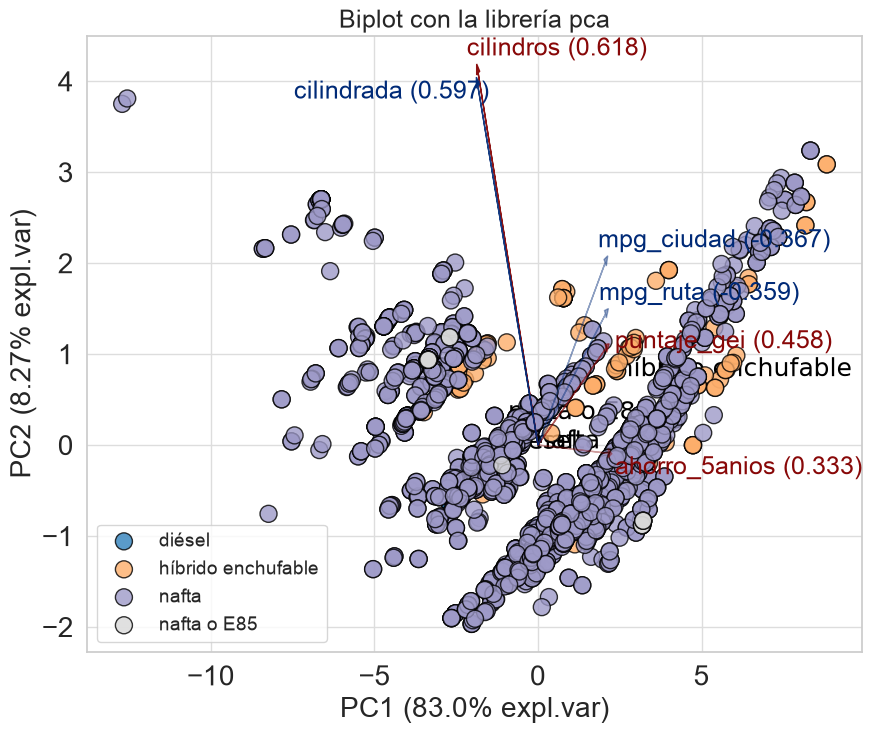

In [51]:
# La librería pca resuelve el biplot en una línea. La uso solo para verificar que mi
# función no esté dibujando cualquier cosa.
from pca import pca as PCAlib

modelo_pca = PCAlib(n_components=3, verbose=40)
Xdf = pd.DataFrame(Z, columns=NUM, index=veh.index)
resultados = modelo_pca.fit_transform(X=Xdf, row_labels=veh["grupo_comb"].astype(str))

print("varianza acumulada:", np.round(100 * resultados["explained_var"], 2))
fig, ax = modelo_pca.biplot(n_feat=6, legend=True, figsize=(10, 8),
                            title="Biplot con la librería pca")
plt.show()

El biplot pone dos cosas en el mismo plano: los 2.795 vehículos proyectados como puntos y
las diez variables como vectores. Ese plano es el de CP1 y CP2, o sea el 91,4 % de la
variación.

Lo primero que se ve es que **casi todos los vectores son horizontales**. Eso quiere decir
que casi toda la información de esas variables está en CP1 y casi nada en CP2. Las únicas
dos flechas que se van para arriba son `cilindros` y `cilindrada`, que es justo lo que había
leído en los loadings del 6d.

Lo segundo es que los vectores reproducen la matriz de correlación del 6a, pero dibujada.
`co2_g_milla` y `barriles_anio` salen una encima de la otra, que es el 0,996 que había
visto. `cilindros` y `cilindrada` casi también. Los tres `mpg` y `puntaje_gei` forman un
abanico apretado hacia la derecha, y `ahorro_5anios` apunta exactamente al lado contrario
de `costo_combustible_anio`. Vectores juntos es correlación positiva, vectores opuestos es
negativa. Todas las flechas son largas, así que ninguna variable se pierde en este plano.

Lo tercero es la nube. Los híbridos enchufables, en rojo, se corren claramente hacia la
derecha, del lado de `mpg` y `ahorro_5anios`. Los diésel se quedan del lado izquierdo. Eso
confirma lo que venía diciendo: el eje horizontal separa autos que rinden y ahorran de autos
de motor grande que consumen y emiten. Un punto bien a la derecha es un híbrido chico y
barato de mantener; uno bien a la izquierda es una pick-up o un deportivo.

También se nota que los puntos forman bandas diagonales en vez de una mancha continua. Es
porque los `mpg` vienen redondeados a enteros, así que las combinaciones posibles caen sobre
una grilla.

### 6f. Cuántas componentes retener

> En función de los análisis realizados en los puntos anteriores. ¿Cuántas componentes
> principales elegiría para explicar el comportamiento del dataset? Justifique esa cantidad.

In [52]:
# Junto los criterios en una sola tabla en vez de decidir de memoria.
criterios = pd.DataFrame({
    "autovalor": resumen_pca["autovalor"],
    "% acumulado": resumen_pca["% acumulado"],
    "¿autovalor > 1?": np.where(resumen_pca["autovalor"] > 1, "sí", "no"),
    "¿pasa el 90 %?": np.where(resumen_pca["% acumulado"] >= 90, "sí", "no"),
})
display(criterios.head(5).round(3))

# El criterio que más me importa: qué variable queda mal representada con cada corte.
comunalidad = pd.DataFrame({f"con {k} CP": (loadings[CP[:k]] ** 2).sum(axis=1)
                            for k in (1, 2, 3)})
comunalidad["gana con la 2ª"] = comunalidad["con 2 CP"] - comunalidad["con 1 CP"]
display(comunalidad.sort_values("gana con la 2ª", ascending=False).round(3))

print(f"peor variable con 1 CP: {comunalidad['con 1 CP'].min():.3f} | "
      f"con 2 CP: {comunalidad['con 2 CP'].min():.3f} | "
      f"con 3 CP: {comunalidad['con 3 CP'].min():.3f}")

,autovalor,% acumulado,¿autovalor > 1?,¿pasa el 90 %?
CP1,8.313,83.098,sí,no
CP2,0.827,91.369,no,sí
CP3,0.426,95.629,no,sí
CP4,0.221,97.840,no,sí
CP5,0.104,98.881,no,sí


,con 1 CP,con 2 CP,con 3 CP,gana con la 2ª
cilindros,0.636,0.953,0.963,0.316
cilindrada,0.643,0.938,0.941,0.295
mpg_ciudad,0.823,0.901,0.958,0.078
mpg_combinado,0.875,0.936,0.993,0.061
mpg_ruta,0.838,0.879,0.934,0.041
puntaje_gei,0.857,0.879,0.969,0.022
co2_g_milla,0.917,0.923,0.987,0.006
barriles_anio,0.915,0.919,0.990,0.005
costo_combustible_anio,0.888,0.891,0.901,0.003
ahorro_5anios,0.921,0.921,0.931,0.000


peor variable con 1 CP: 0.636 | con 2 CP: 0.879 | con 3 CP: 0.901


**Me quedo con dos componentes.**

Los criterios no coinciden, así que los miro de a uno.

Kaiser, que retiene las componentes con autovalor mayor a 1, dice que me quede con una
sola: CP2 vale 0,827 y no llega al corte. El codo del scree del 6c cae en CP2. El umbral
del 90 % de varianza acumulada lo cruzo recién con dos componentes, 91,37 %. Con tres
llegaría al 95,63 %.

Lo que me hace decidir es la tabla de comunalidades. Si retengo una sola componente,
`cilindros` queda representada en 0,636 y `cilindrada` en 0,643. Son las dos peores del
dataset y se me pierde más de un tercio de cada una. Al agregar la segunda componente
saltan a 0,953 y 0,938. Ninguna otra variable gana más de 0,08. O sea que CP2 existe casi
únicamente para recuperar el tamaño del motor, que es información real y que CP1 no tiene.
Tirarla por 0,17 de autovalor me parece un precio caro.

Contra la tercera componente el argumento es el inverso. Sube la variable peor representada
de 0,879 a 0,901, una mejora chica, y a cambio agrega un eje que no tengo cómo interpretar:
en los loadings del 6d, CP3 no tiene ninguna carga clara.

Con dos componentes me quedo con el 91,4 % de la variación, y la variable peor
representada conserva casi el 88 % de su varianza. CP1 es el eje eficiencia contra consumo,
CP2 es el tamaño del motor. Las dos se explican en una frase, que es lo que le pido a una
reducción de dimensionalidad.

Esto cierra lo que venía viendo desde el 6a: diez columnas, pero en los hechos dos ideas.
Buena parte de la redundancia era por construcción, porque la EPA deriva unas columnas de
otras, y el PCA la encontró sin que yo le dijera nada.